In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTETomek
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier


from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

import joblib
import os

import warnings
warnings.filterwarnings("ignore")



from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score,precision_recall_curve, recall_score, RocCurveDisplay, f1_score, ConfusionMatrixDisplay, roc_curve

In [276]:
df = pd.read_csv(r"C:\Users\ADEGBITE EMMANUEL\Desktop\DATA SCEINCE CLASS\healthcare-dataset-stroke-data.csv")

In [277]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [278]:
df.shape

(5110, 12)

In [279]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


**Checking for Null values**

In [280]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

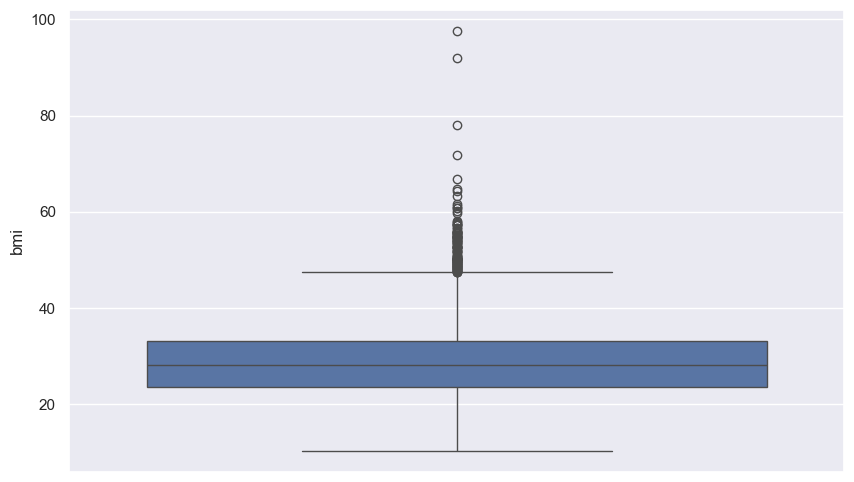

In [281]:
#checking for outliers to determine the right parameter to fill our null values
sns.boxplot(df["bmi"])

plt.show()

In [282]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [283]:
df.shape


(5110, 12)

In [284]:
#Filling The Null values for bmi

df['bmi']= df["bmi"].fillna(df['bmi'].median())

df["bmi"]

0       36.6
1       28.1
2       32.5
3       34.4
4       24.0
        ... 
5105    28.1
5106    40.0
5107    30.6
5108    25.6
5109    26.2
Name: bmi, Length: 5110, dtype: float64

In [285]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [286]:
df.shape

(5110, 12)

In [287]:
#change the age datatype

df['age'] = df['age'].astype('int')

df["age"].value_counts

<bound method IndexOpsMixin.value_counts of 0       67
1       61
2       80
3       49
4       79
        ..
5105    80
5106    81
5107    35
5108    51
5109    44
Name: age, Length: 5110, dtype: int64>

In [288]:
df = df[df["gender"] !="Other"]

In [289]:
#Checking for datatype

df.dtypes

id                     int64
gender                object
age                    int64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [290]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000
mean,36513.985516,43.218634,0.097475,0.054022,106.140399,28.863300,0.048738
std,21162.008804,22.634799,0.296633,0.226084,45.285004,7.699785,0.215340
min,67.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17740.000000,25.000000,0.000000,0.000000,77.240000,23.800000,0.000000
50%,36922.000000,45.000000,0.000000,0.000000,91.880000,28.100000,0.000000
75%,54643.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [291]:
#To check for duplicate

df.duplicated().sum()

np.int64(0)

In [292]:
#To remove any leading and trailing spaces in the dataset

df.columns = df.columns.str.strip()

In [293]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [294]:
#Captitalizing Dataset Headings

df.columns = df.columns.str.capitalize()

In [295]:
df.columns

Index(['Id', 'Gender', 'Age', 'Hypertension', 'Heart_disease', 'Ever_married',
       'Work_type', 'Residence_type', 'Avg_glucose_level', 'Bmi',
       'Smoking_status', 'Stroke'],
      dtype='object')

## EXPLORATORY DATA ANALYSIS.

In [296]:
df.head()

,Id,Gender,Age,Hypertension,Heart_disease,Ever_married,Work_type,Residence_type,Avg_glucose_level,Bmi,Smoking_status,Stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [297]:
average_age = df["Age"].mean()

In [298]:
average_age

np.float64(43.21863378351928)

In [299]:
print(f" the average of the client is {average_age} !")

 the average of the client is 43.21863378351928 !


<function matplotlib.pyplot.show(close=None, block=None)>

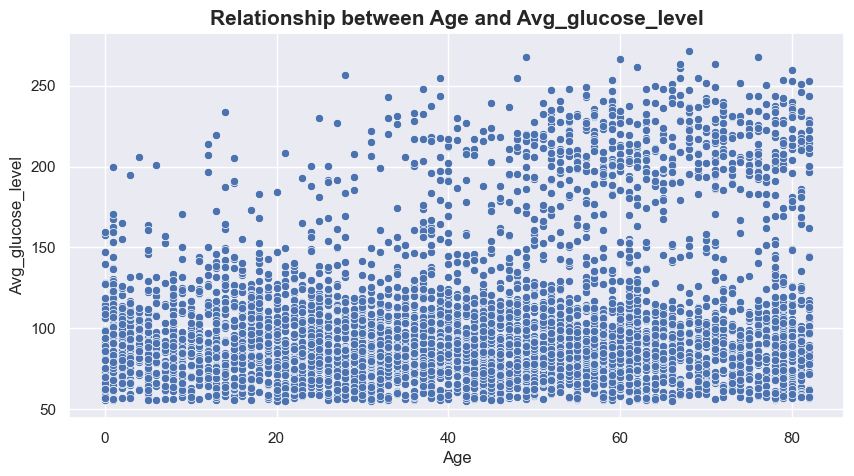

In [300]:
## checking for the relationship between Age and Avg_glucose_level
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x='Age',y='Avg_glucose_level')
plt.title("Relationship between Age and Avg_glucose_level", fontsize = 15, fontweight = 'bold')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

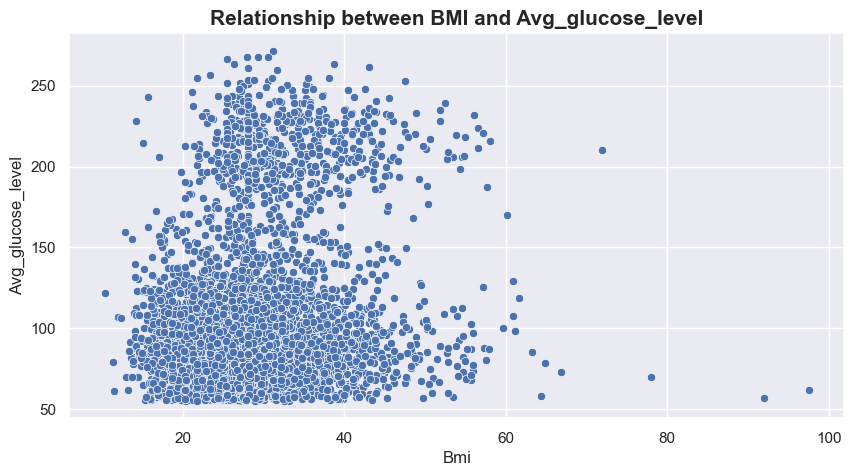

In [301]:
## checking for the relationship between BMI and Avg_glucose_level
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x='Bmi',y='Avg_glucose_level')
plt.title("Relationship between BMI and Avg_glucose_level", fontsize = 15, fontweight = 'bold')
plt.show

In [302]:
##creating a function to group the age
def age_group(Age):
    
    if Age<= 18:
        return "Young"
    elif Age <=35:
        return "Youth"
    elif Age < 65:
        return "Elderly"
    else:
        return "Aged"

In [303]:
df['Age_group'] = df['Age'].apply(age_group)

In [304]:
df.head()

,Id,Gender,Age,Hypertension,Heart_disease,Ever_married,Work_type,Residence_type,Avg_glucose_level,Bmi,Smoking_status,Stroke,Age_group
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Aged
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,Elderly
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Aged
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Elderly
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Aged


In [305]:
df.query("Stroke==1").groupby("Age_group")["Id"].size().reset_index()

,Age_group,Id
0,Aged,159
1,Elderly,87
2,Young,2
3,Youth,1


In [306]:
#Tabular representation of Smoking status and Stroke Relationship
pd.crosstab(df["Smoking_status"],df["Stroke"])

Stroke,0,1
Smoking_status,,
Unknown,1497,47
formerly smoked,814,70
never smoked,1802,90
smokes,747,42


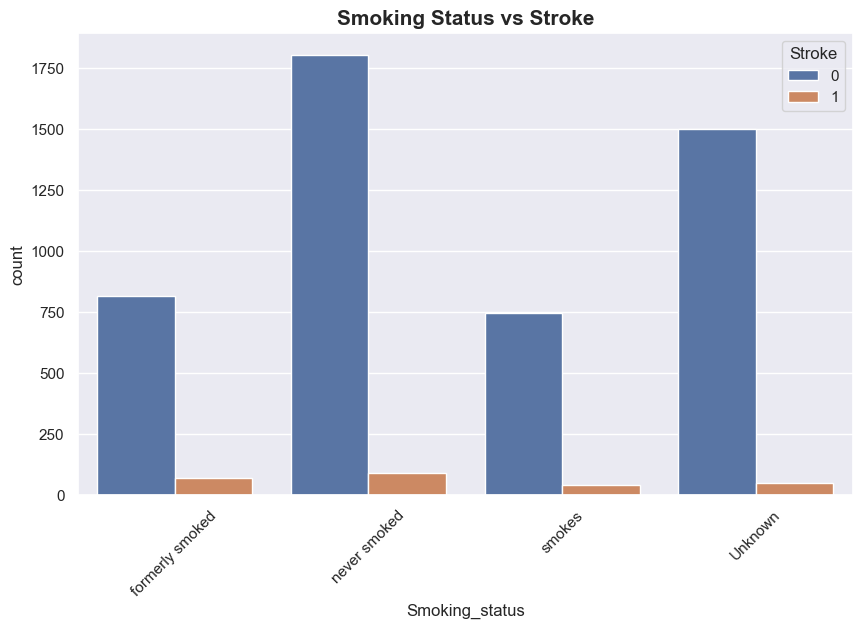

In [307]:
#Grpahical representation of smoking status and stroke relationship

sns.countplot(x='Smoking_status', hue='Stroke', data=df)
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"]=(10, 6)
plt.xticks(rotation=45)
plt.title("Smoking Status vs Stroke", fontsize = 15, fontweight = 'bold')
plt.show()

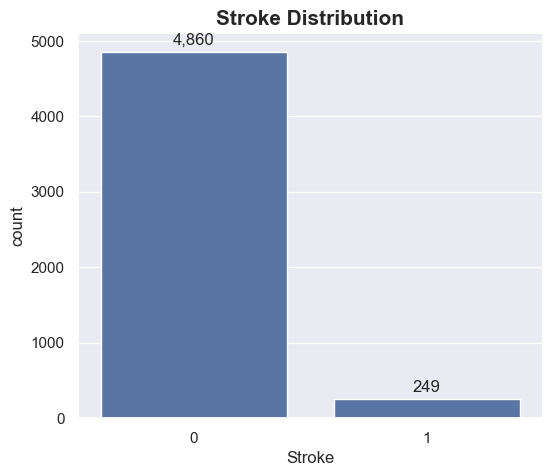

Stroke
0    95.126248
1     4.873752
Name: proportion, dtype: float64

In [308]:
#Stroke Distribution (Which is the target variable)

plt.figure(figsize=(6,5))
ax=sns.countplot(x='Stroke', data=df)
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"]=(10, 6)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)
plt.title("Stroke Distribution", fontsize = 15, fontweight = 'bold')
plt.show()


df['Stroke'].value_counts(normalize=True) * 100

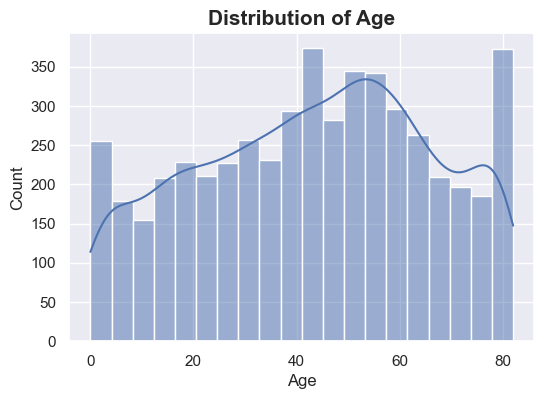

In [309]:
#Distribtion of Numerical Features

num_cols = ['Age']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.set_theme(style="darkgrid", palette="deep")
    plt.rcParams["figure.figsize"]=(10, 6)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}", fontsize = 15, fontweight = 'bold')
    plt.show()

**From the graph above, the negatively skewed distribution means that the population samples comprises of young people and they are at a lower risk of acquiring stroke diseases**

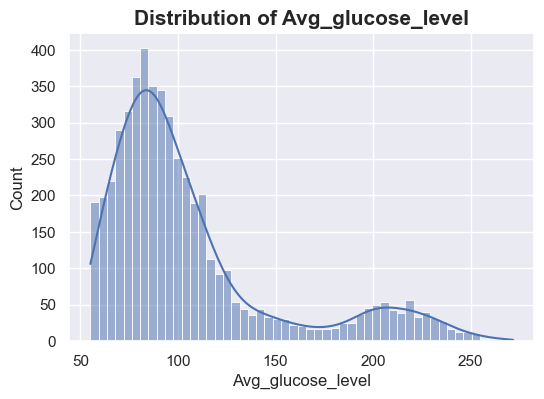

In [310]:
#Distribtion of Numerical Features

num_cols = ['Avg_glucose_level']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.set_theme(style="darkgrid", palette="deep")
    plt.rcParams["figure.figsize"]=(10, 6)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}", fontsize = 15, fontweight = 'bold')
    plt.show()

**From the dataset above, a positively skewed mean that most people glucose level are at a normal stage and they are at a low risk of aquiring stroke**

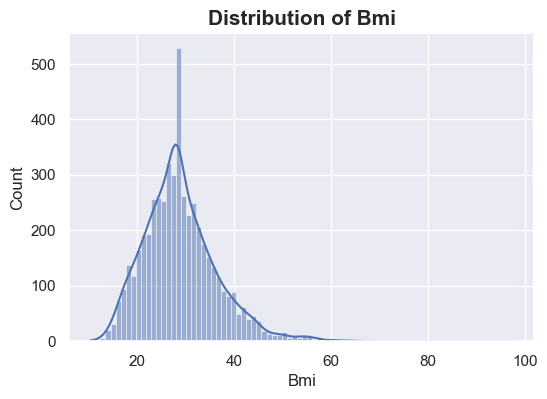

In [311]:
#Distribtion of Numerical Features

num_cols = ['Bmi']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.set_theme(style="darkgrid", palette="deep")
    plt.rcParams["figure.figsize"]=(10, 6)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}", fontsize = 15, fontweight = 'bold')
    plt.show()

**Most people have a normal body mass index, this imples that they are not malnourise which make abit not vulnerable to stroke disease**

In [312]:
gender_count =df["Gender"].value_counts()
gender_count

Gender
Female    2994
Male      2115
Name: count, dtype: int64

In [313]:
gender_count.index

Index(['Female', 'Male'], dtype='object', name='Gender')

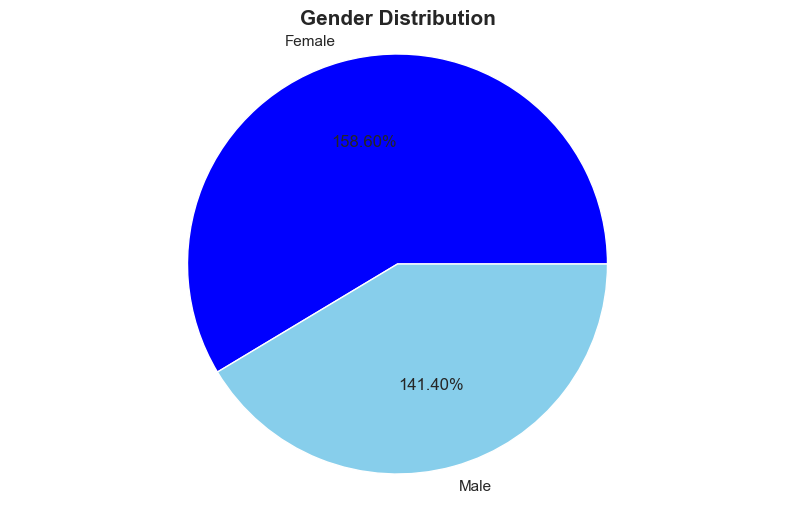

In [314]:
plt.pie(gender_count, labels = gender_count.index, autopct = '1%.2f%%', colors = ["blue", "skyblue", "lightgrey" ])
plt.title("Gender Distribution", fontsize = 15, fontweight = 'bold')
plt.axis("equal")
plt.show()

**From the Piechart, female clients consitutes the higher percentage of people access for stroke diseases, this make sense because in most society female are known to be more receptive to medical exercise than others genders and this place then at a safer side of getting adverse stroke because they would have taken proper measures to reduce stroke after examination**

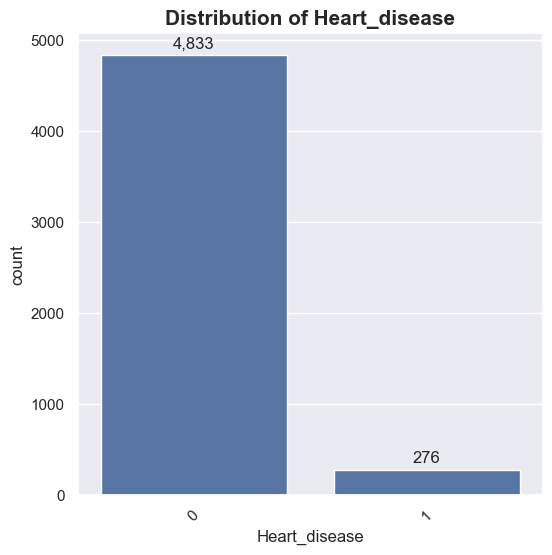

In [315]:

cat_cols = ['Heart_disease']

for col in cat_cols:
    plt.figure(figsize=(6,6))
    sns.set_theme(style="darkgrid", palette="deep")
    plt.rcParams["figure.figsize"]=(10, 6)
    ax=sns.countplot(x=col, data=df)
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}", fontsize = 15, fontweight = 'bold')
    plt.show()

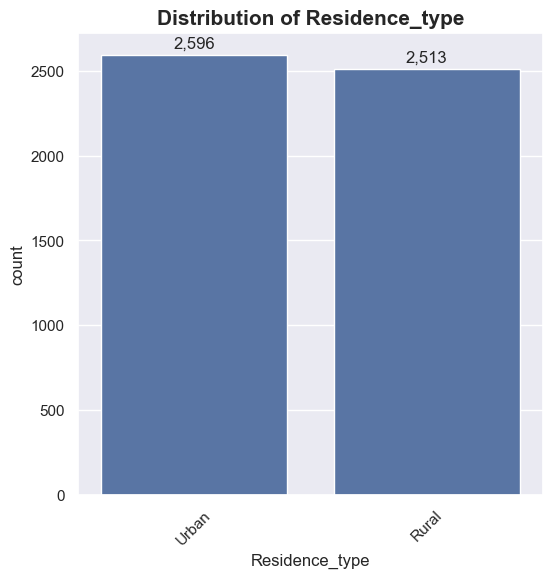

In [316]:

cat_cols =['Residence_type']

for col in cat_cols:
    plt.figure(figsize=(6,6))
    sns.set_theme(style="darkgrid", palette="deep")
    plt.rcParams["figure.figsize"]=(10, 6)
    ax=sns.countplot(x=col, data=df)
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}", fontsize = 15, fontweight = 'bold')
    plt.show()

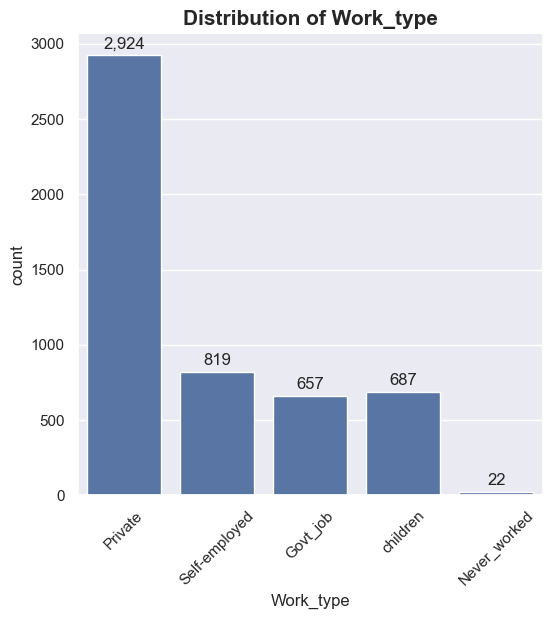

In [317]:

cat_cols = ['Work_type']

for col in cat_cols:
    plt.figure(figsize=(6,6))
    sns.set_theme(style="darkgrid", palette="deep")
    plt.rcParams["figure.figsize"]=(10, 6)
    ax=sns.countplot(x=col, data=df)
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}", fontsize = 15, fontweight = 'bold')
    plt.show()


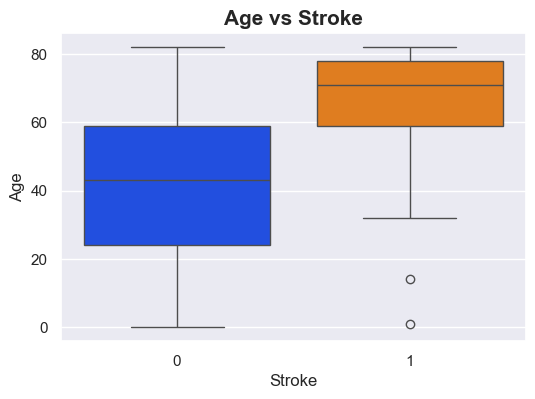

In [318]:
#Bivariate Analysis of (Stroke and Age)

plt.figure(figsize=(6,4))
sns.boxplot(x='Stroke', y='Age', data=df, palette = "bright")
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"]=(10, 6)
plt.title("Age vs Stroke", fontsize = 15, fontweight = 'bold')
plt.show()

**From the box plot above, we can say that a patient who is at a higher risk of getting stroke is far older than the person who is not at risk of getting stroke because the median values for high risk stroke is higher than people with low risk stroke, its mean that as your age increases, the possibility of you acquiring the stroke also increases**

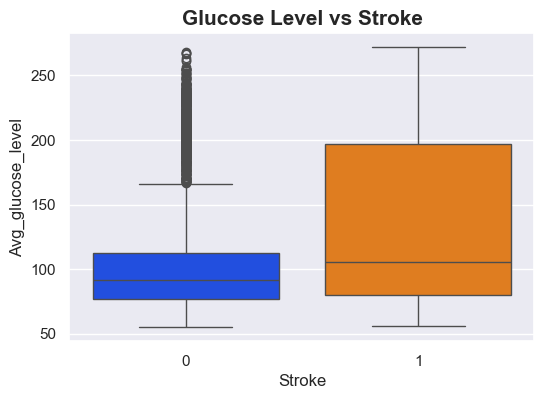

In [319]:
#Stroke and Average Glucose Level

plt.figure(figsize=(6,4))
sns.boxplot(x='Stroke', y='Avg_glucose_level', data=df,palette = "bright")
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"]=(10, 6)
plt.title("Glucose Level vs Stroke", fontsize = 15, fontweight = 'bold')
plt.show()

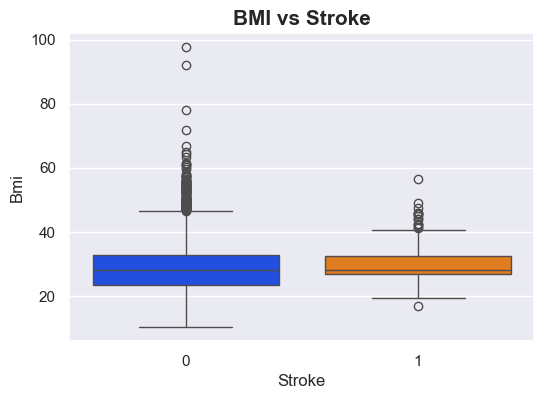

In [320]:
#Stroke and BMI

plt.figure(figsize=(6,4))
sns.boxplot(x='Stroke', y='Bmi', data=df, palette = "bright")
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"]=(10, 6)
plt.title("BMI vs Stroke", fontsize = 15, fontweight = 'bold')
plt.show()

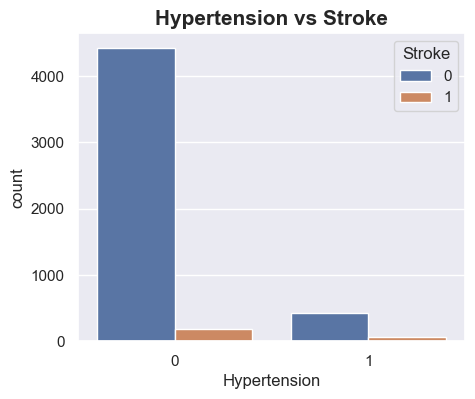

In [321]:
#Stroke and Hypertension

plt.figure(figsize=(5,4))
sns.countplot(x='Hypertension', hue='Stroke', data=df)
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"]=(10, 6)
plt.title("Hypertension vs Stroke", fontsize = 15, fontweight = 'bold')
plt.show()

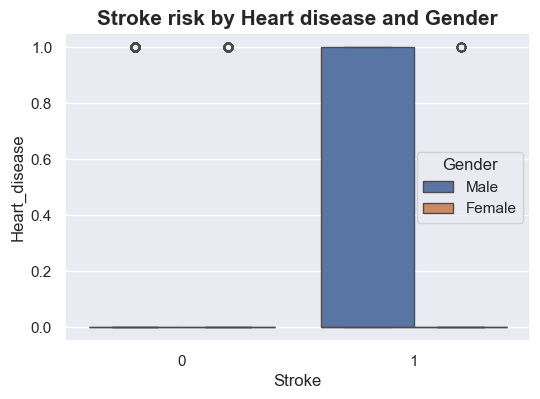

In [322]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Stroke', y='Heart_disease', data=df,hue='Gender')
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"]=(10, 6)
plt.title("Stroke risk by Heart disease and Gender", fontsize = 15, fontweight = 'bold')
plt.show()

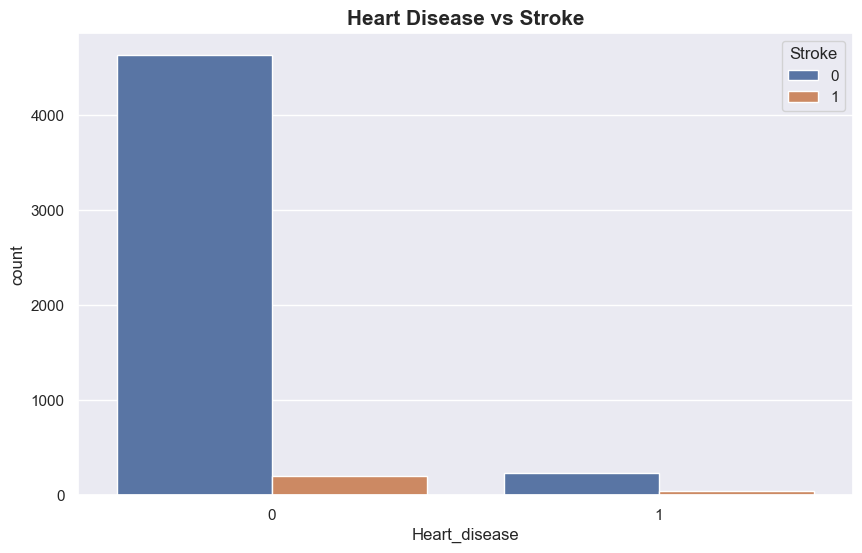

In [323]:
sns.countplot(x='Heart_disease', hue='Stroke', data=df)
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"]=(10, 6)
plt.title("Heart Disease vs Stroke", fontsize = 15, fontweight = 'bold')
plt.show()

## Classification Model 

### Feature Selection 

In [324]:
df.head()

,Id,Gender,Age,Hypertension,Heart_disease,Ever_married,Work_type,Residence_type,Avg_glucose_level,Bmi,Smoking_status,Stroke,Age_group
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Aged
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,Elderly
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Aged
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Elderly
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Aged


In [325]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 5109 non-null   int64  
 1   Gender             5109 non-null   object 
 2   Age                5109 non-null   int64  
 3   Hypertension       5109 non-null   int64  
 4   Heart_disease      5109 non-null   int64  
 5   Ever_married       5109 non-null   object 
 6   Work_type          5109 non-null   object 
 7   Residence_type     5109 non-null   object 
 8   Avg_glucose_level  5109 non-null   float64
 9   Bmi                5109 non-null   float64
 10  Smoking_status     5109 non-null   object 
 11  Stroke             5109 non-null   int64  
 12  Age_group          5109 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 558.8+ KB


In [326]:
# dropping the id column

x = df.drop(columns = ["Id", "Age_group", "Stroke"])

y = df["Stroke"]


In [327]:
x

,Gender,Age,Hypertension,Heart_disease,Ever_married,Work_type,Residence_type,Avg_glucose_level,Bmi,Smoking_status
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked
...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,83.75,28.1,never smoked
5106,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked
5107,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked
5108,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked


In [328]:
y.value_counts()

Stroke
0    4860
1     249
Name: count, dtype: int64

In [329]:
y

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: Stroke, Length: 5109, dtype: int64

In [330]:
y.shape

(5109,)

### Feature Encoding

In [331]:
x

,Gender,Age,Hypertension,Heart_disease,Ever_married,Work_type,Residence_type,Avg_glucose_level,Bmi,Smoking_status
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked
...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,83.75,28.1,never smoked
5106,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked
5107,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked
5108,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked


In [332]:
#Encoding categorical features into numeric using OneHotEncoder

cat_cols = ["Gender", "Ever_married", "Work_type", "Residence_type", "Smoking_status", "Hypertension", "Heart_disease"]

one_hot_encoder = OneHotEncoder(drop = "first", sparse_output = False)

encoded_cat = one_hot_encoder.fit_transform(x[cat_cols])

encoded_cat_df = pd.DataFrame(encoded_cat, columns = one_hot_encoder.get_feature_names_out(cat_cols), index = x.index
)


In [333]:
x = pd.concat([x, encoded_cat_df], axis=1)

x = x.drop(cat_cols, axis=1)

In [334]:
x

,Age,Avg_glucose_level,Bmi,Gender_Male,Ever_married_Yes,Work_type_Never_worked,Work_type_Private,Work_type_Self-employed,Work_type_children,Residence_type_Urban,Smoking_status_formerly smoked,Smoking_status_never smoked,Smoking_status_smokes,Hypertension_1,Heart_disease_1
0,67,228.69,36.6,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,61,202.21,28.1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,80,105.92,32.5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,49,171.23,34.4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,79,174.12,24.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,80,83.75,28.1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
5106,81,125.20,40.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5107,35,82.99,30.6,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5108,51,166.29,25.6,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [335]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             5109 non-null   int64  
 1   Avg_glucose_level               5109 non-null   float64
 2   Bmi                             5109 non-null   float64
 3   Gender_Male                     5109 non-null   float64
 4   Ever_married_Yes                5109 non-null   float64
 5   Work_type_Never_worked          5109 non-null   float64
 6   Work_type_Private               5109 non-null   float64
 7   Work_type_Self-employed         5109 non-null   float64
 8   Work_type_children              5109 non-null   float64
 9   Residence_type_Urban            5109 non-null   float64
 10  Smoking_status_formerly smoked  5109 non-null   float64
 11  Smoking_status_never smoked     5109 non-null   float64
 12  Smoking_status_smokes           5109 no

### Feature Correlation

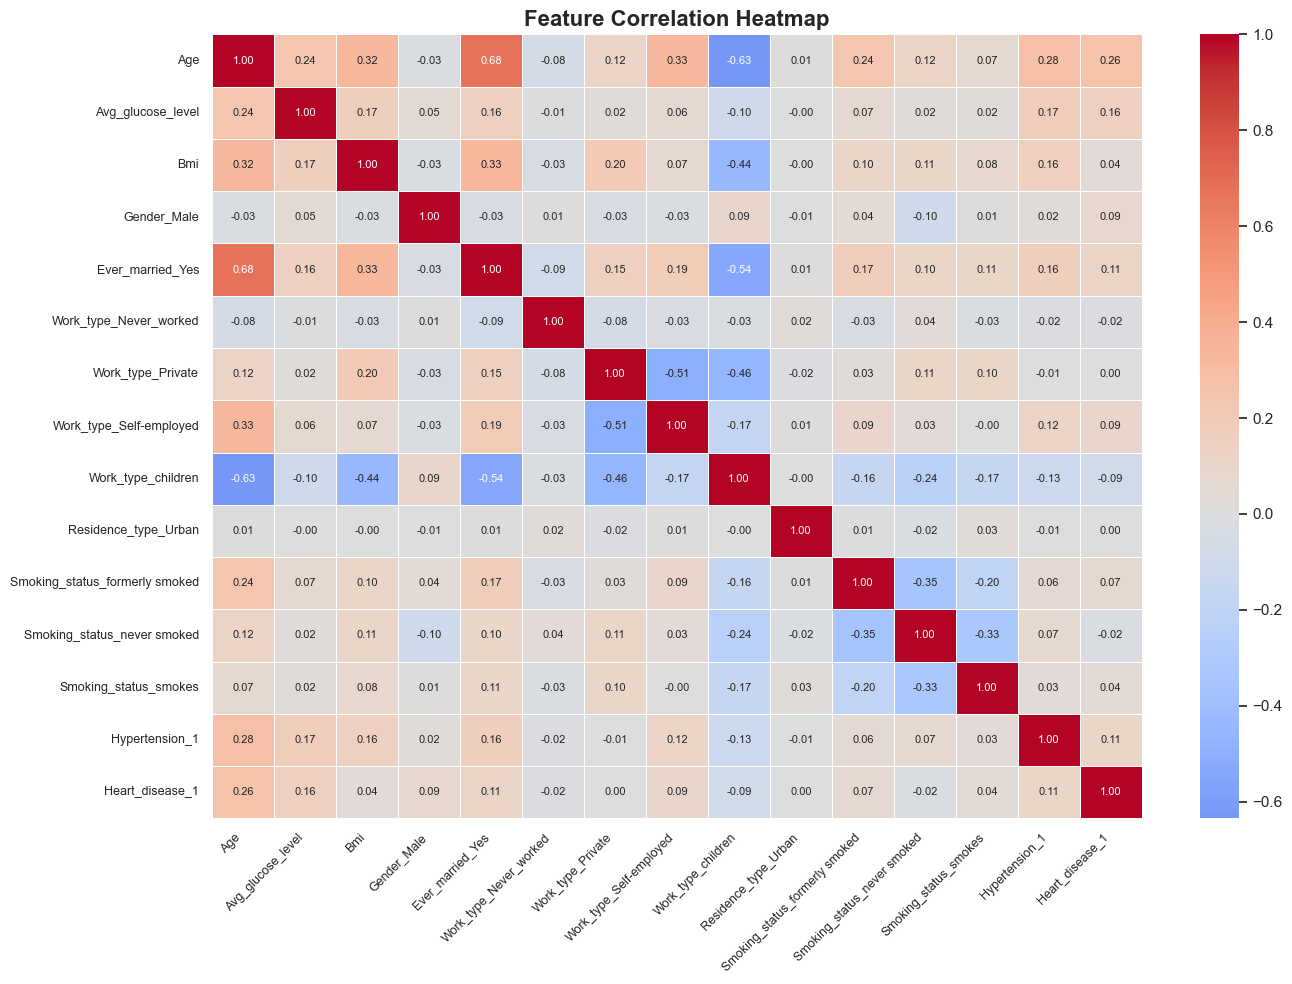

In [336]:
#Correltion Heatmap

plt.figure(figsize=(14, 10))
sns.heatmap(
    x.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### Train Test Split

In [337]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

### Cross Validation

In [338]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Feature Scaling

In [339]:
scaled = StandardScaler()
x_train_scaled = scaled.fit_transform(x_train)
x_test_scaled = scaled.transform(x_test)

In [340]:
x.head()

,Age,Avg_glucose_level,Bmi,Gender_Male,Ever_married_Yes,Work_type_Never_worked,Work_type_Private,Work_type_Self-employed,Work_type_children,Residence_type_Urban,Smoking_status_formerly smoked,Smoking_status_never smoked,Smoking_status_smokes,Hypertension_1,Heart_disease_1
0,67,228.69,36.6,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,61,202.21,28.1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,80,105.92,32.5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,49,171.23,34.4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,79,174.12,24.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


###  Logistic Regression

Best Parameters: {'logreg__C': 10, 'logreg__penalty': 'l1', 'smote__k_neighbors': 7}

Accuracy:  0.7427
Precision: 0.1365
Recall:    0.8000
F1 Score:  0.2332
AUC-ROC:   0.8403


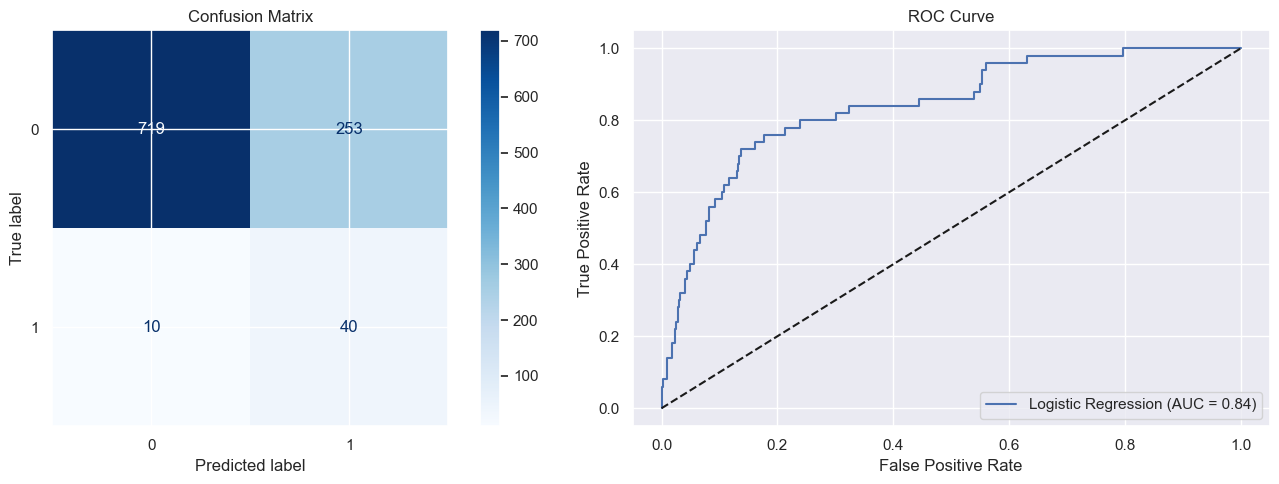

In [341]:
# Pipeline: SMOTE + Logistic Regression

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('logreg', LogisticRegression(max_iter=1000, solver='liblinear'))
])

#  Grid for Tuning
param_grid = {
    'smote__k_neighbors': [3, 5, 7],
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2']
}

# Run Grid Search (Optimizing for F1-score)
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(x_train_scaled, y_train)

# Predictions
log_model = grid_search.best_estimator_
y_pred = log_model.predict(x_test_scaled)
y_proba = log_model.predict_proba(x_test_scaled)[:, 1] # Needed for AUC-ROC

# Calculation of Metrics
print(f"Best Parameters: {grid_search.best_params_}\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")

# Visualization 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(log_model, x_test_scaled, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title('Confusion Matrix')

# AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.2f})')
ax[1].plot([0, 1], [0, 1], 'k--') # Diagonal line
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Random Forest

Best Parameters: {'logreg__C': 10, 'logreg__penalty': 'l1', 'smote__k_neighbors': 7}

Accuracy:  0.8317
Precision: 0.1280
Recall:    0.4200
Random Forest - F1 Score: 0.1963
Random Forest - AUC-ROC: 0.7768


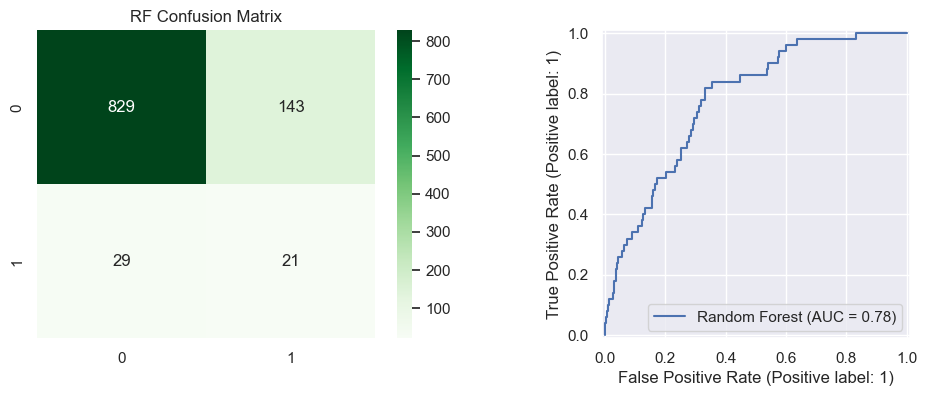

In [342]:
# Pipeline and Gidsearch
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'smote__k_neighbors': [3, 5],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(x_train_scaled, y_train)

# Prediction
y_pred_rf = rf_grid.predict(x_test_scaled)
y_proba_rf = rf_grid.predict_proba(x_test_scaled)[:, 1]

print(f"Best Parameters: {grid_search.best_params_}\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest - F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest - AUC-ROC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('RF Confusion Matrix')
RocCurveDisplay.from_estimator(rf_grid, x_test_scaled, y_test, ax=ax[1], name='Random Forest')
plt.show()

## XGBOOST

--- XGBOOST RESULTS ---
Best Parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Accuracy:  0.8405
Precision: 0.1657
Recall:    0.5600
F1 Score:  0.2557
AUC-ROC:   0.8107


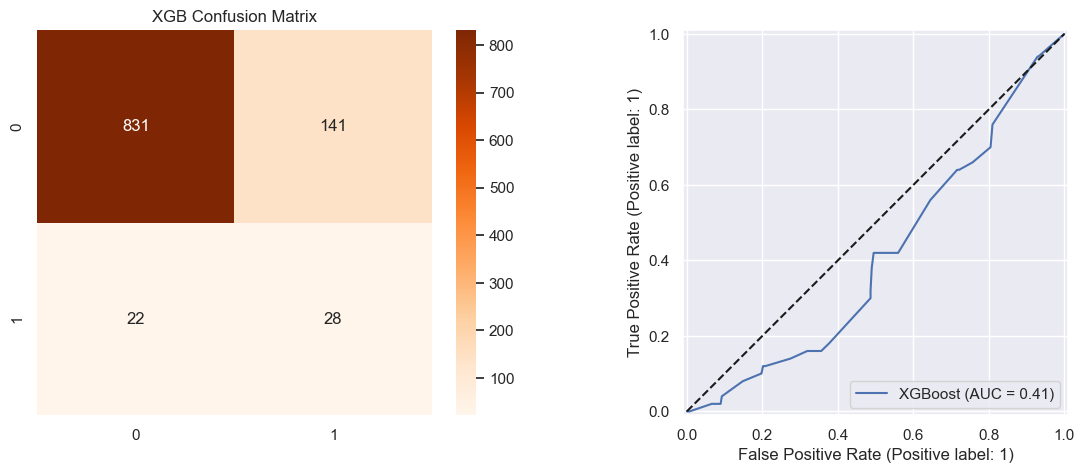

In [343]:
# Pipeline & GridSearch
xgb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

xgb_param_grid = {
    'xgb__learning_rate': [0.1, 0.2],
    'xgb__max_depth': [3, 5],
    'xgb__n_estimators': [100, 200]
}

xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=skf, scoring='f1', n_jobs=-1)
xgb_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_xgb = xgb_grid.predict(x_test_scaled)
y_proba_xgb = xgb_grid.predict_proba(x_test_scaled)[:, 1]

# Output Results
print("--- XGBOOST RESULTS ---")
print(f"Best Parameters: {xgb_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")

# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('XGB Confusion Matrix')
RocCurveDisplay.from_estimator(xgb_grid, x_test, y_test, ax=ax[1], name='XGBoost')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

### SUPPORT VECTOR CLASSIFIER

--- SVC RESULTS ---
Best Parameters: {'svc__C': 0.1, 'svc__kernel': 'rbf'}
Accuracy:  0.7250
Precision: 0.1262
Recall:    0.7800
F1 Score:  0.2173
AUC-ROC:   0.8109


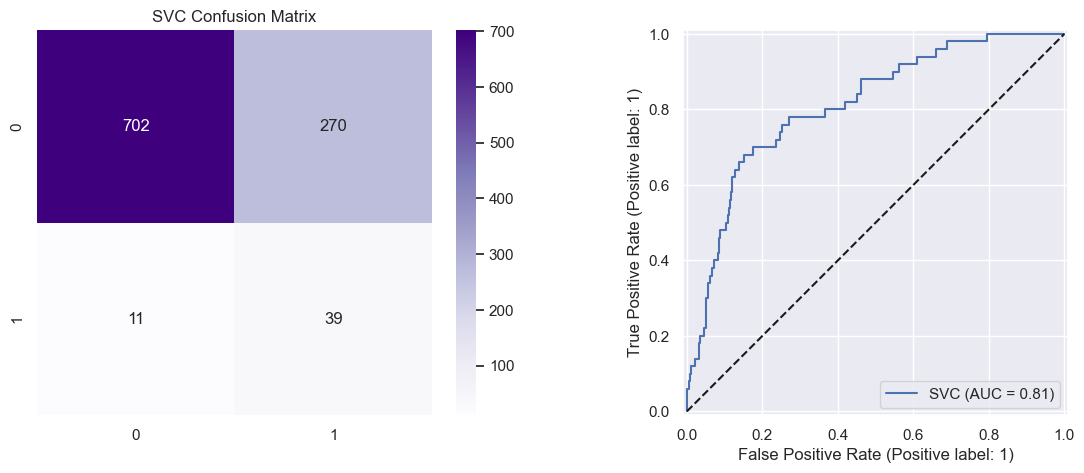

In [344]:
# Pipeline & GridSearch
svc_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
])

svc_param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['rbf']
}

svc_grid = GridSearchCV(svc_pipeline, svc_param_grid, cv=skf, scoring='f1', n_jobs=-1)
svc_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_svc = svc_grid.predict(x_test_scaled)
y_proba_svc = svc_grid.predict_proba(x_test_scaled)[:, 1]

# Output Results
print("--- SVC RESULTS ---")
print(f"Best Parameters: {svc_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svc):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svc):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_svc):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_svc):.4f}")

# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Purples', ax=ax[0])
ax[0].set_title('SVC Confusion Matrix')
RocCurveDisplay.from_estimator(svc_grid, x_test_scaled, y_test, ax=ax[1], name='SVC')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

### ADA BOOST

--- ADABOOST RESULTS ---
Best Parameters: {'ada__learning_rate': 1.0, 'ada__n_estimators': 100}
Accuracy:  0.7710
Precision: 0.1434
Recall:    0.7400
F1 Score:  0.2403
AUC-ROC:   0.8103


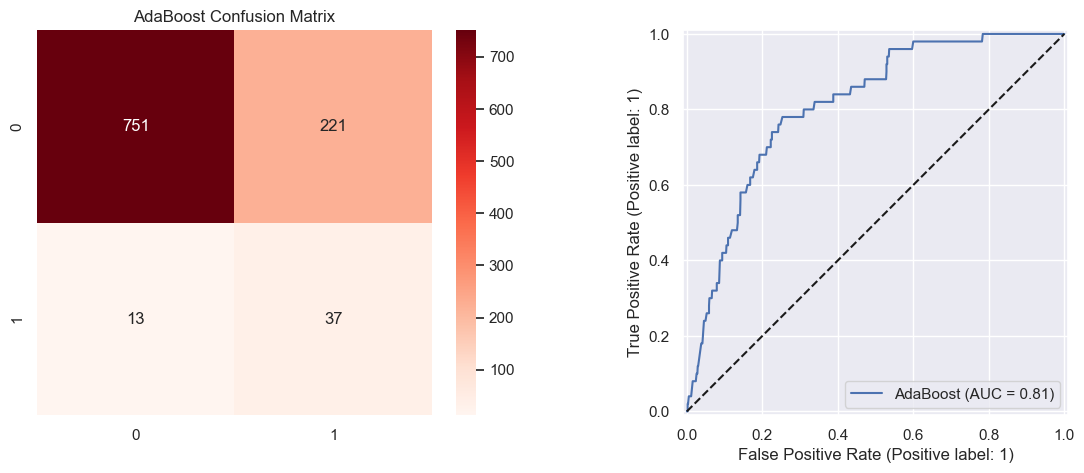

In [345]:
# Pipeline & GridSearch
ada_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('ada', AdaBoostClassifier(random_state=42))
])

ada_param_grid = {
    'ada__n_estimators': [50, 100],
    'ada__learning_rate': [0.1, 1.0]
}

ada_grid = GridSearchCV(ada_pipeline, ada_param_grid, cv=5, scoring='f1', n_jobs=-1)
ada_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_ada = ada_grid.predict(x_test_scaled)
y_proba_ada = ada_grid.predict_proba(x_test_scaled)[:, 1]

# Output Results
print("--- ADABOOST RESULTS ---")
print(f"Best Parameters: {ada_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ada):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ada):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_ada):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_ada):.4f}")

# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', cmap='Reds', ax=ax[0])
ax[0].set_title('AdaBoost Confusion Matrix')
RocCurveDisplay.from_estimator(ada_grid, x_test_scaled, y_test, ax=ax[1], name='AdaBoost')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

### Balanced Bagging Classifier

--- BALANCED BAGGING RESULTS ---
Best Parameters: {'bbc__n_estimators': 50}
Accuracy:  0.7750
Precision: 0.1484
Recall:    0.7600
F1 Score:  0.2484
AUC-ROC:   0.8144


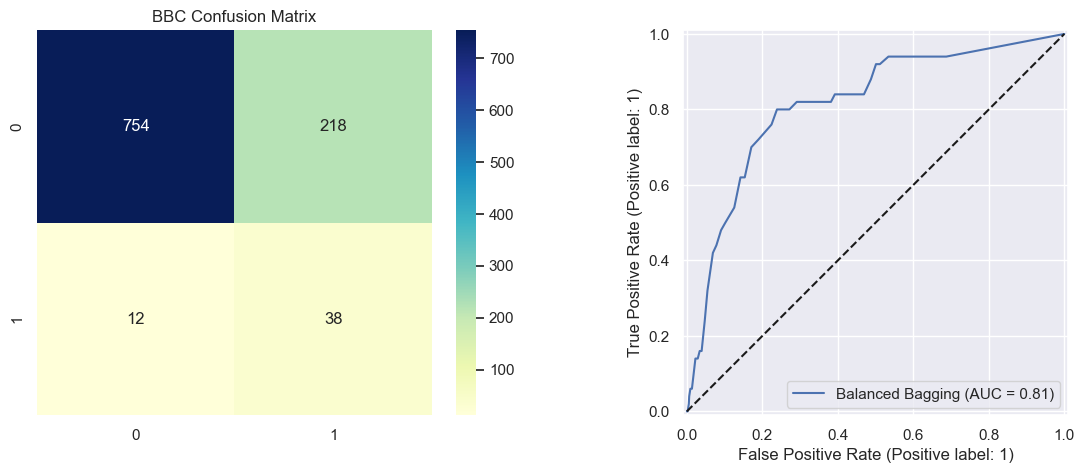

In [346]:
# Pipeline & GridSearch
bbc_pipeline = Pipeline([
    ('bbc', BalancedBaggingClassifier(random_state=42))
])

bbc_param_grid = {
    'bbc__n_estimators': [10, 50]
}

bbc_grid = GridSearchCV(bbc_pipeline, bbc_param_grid, cv=5, scoring='f1', n_jobs=-1)
bbc_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_bbc = bbc_grid.predict(x_test_scaled)
y_proba_bbc = bbc_grid.predict_proba(x_test_scaled)[:, 1]

# Output Results
print("--- BALANCED BAGGING RESULTS ---")
print(f"Best Parameters: {bbc_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_bbc):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bbc):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_bbc):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_bbc):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_bbc):.4f}")

# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_bbc), annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('BBC Confusion Matrix')
RocCurveDisplay.from_estimator(bbc_grid, x_test_scaled, y_test, ax=ax[1], name='Balanced Bagging')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

### K-Nearest Neighbours

--- K-NEAREST NEIGHBORS RESULTS ---
Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'uniform', 'smote__k_neighbors': 5}
Accuracy:  0.8297
Precision: 0.1125
Recall:    0.3600
F1 Score:  0.1714
AUC-ROC:   0.6668


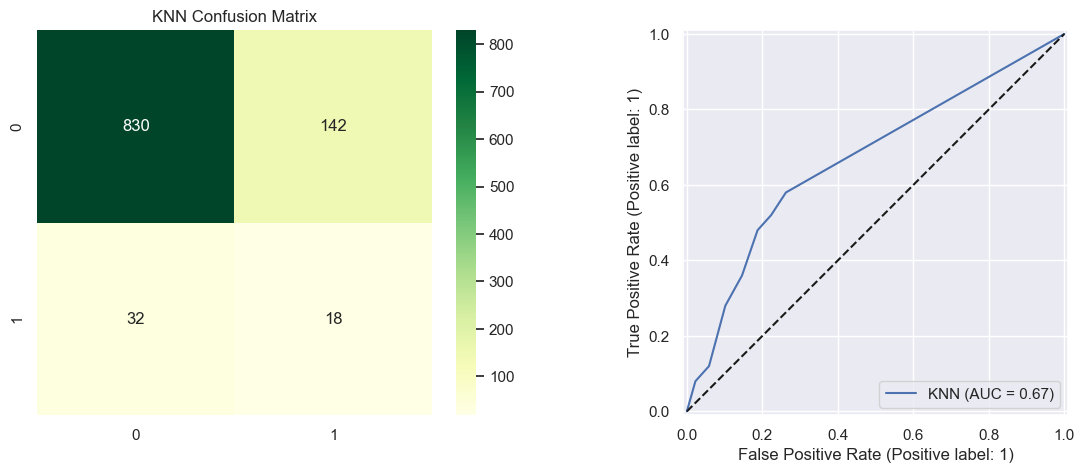

In [347]:
# Pipeline & GridSearch

knn_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'smote__k_neighbors': [3, 5],
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(knn_pipeline, knn_param_grid, cv=5, scoring='f1', n_jobs=-1)
knn_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_knn = knn_grid.predict(x_test_scaled)
y_proba_knn = knn_grid.predict_proba(x_test_scaled)[:, 1]

# Output Results
print("--- K-NEAREST NEIGHBORS RESULTS ---")
print(f"Best Parameters: {knn_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_knn):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_knn):.4f}")

# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='YlGn', ax=ax[0])
ax[0].set_title('KNN Confusion Matrix')
RocCurveDisplay.from_estimator(knn_grid, x_test_scaled, y_test, ax=ax[1], name='KNN')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

### Gaussian Naive Bayes

--- GAUSSIAN NAIVE BAYES RESULTS ---
Best Parameters: {'gnb__var_smoothing': 1e-06, 'smote__k_neighbors': 5}
Accuracy:  0.3748
Precision: 0.0713
Recall:    0.9800
F1 Score:  0.1330
AUC-ROC:   0.7941


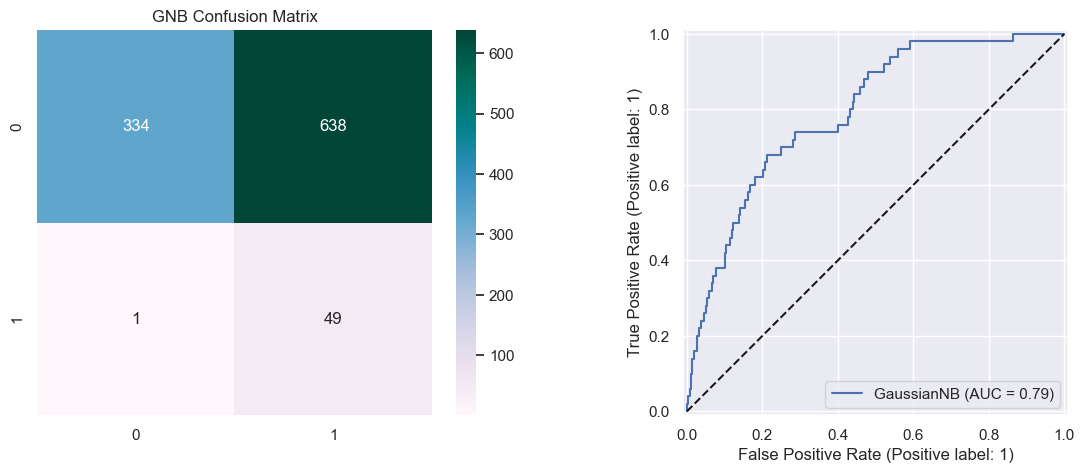

In [348]:
# Pipeline and Grid search

gnb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('gnb', GaussianNB())
])


gnb_param_grid = {
    'smote__k_neighbors': [3, 5],
    'gnb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

gnb_grid = GridSearchCV(gnb_pipeline, gnb_param_grid, cv=5, scoring='f1', n_jobs=-1)
gnb_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_gnb = gnb_grid.predict(x_test_scaled)
y_proba_gnb = gnb_grid.predict_proba(x_test_scaled)[:, 1]

# Output Results
print("--- GAUSSIAN NAIVE BAYES RESULTS ---")
print(f"Best Parameters: {gnb_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gnb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gnb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gnb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_gnb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_gnb):.4f}")

# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_gnb), annot=True, fmt='d', cmap='PuBuGn', ax=ax[0])
ax[0].set_title('GNB Confusion Matrix')
RocCurveDisplay.from_estimator(gnb_grid, x_test_scaled, y_test, ax=ax[1], name='GaussianNB')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

### Easy Ensemble Classifier

--- EASY ENSEMBLE RESULTS ---
Best Parameters: {'ee__n_estimators': 20}
Accuracy:  0.6575
Precision: 0.1094
Recall:    0.8400
F1 Score:  0.1935
AUC-ROC:   0.8356


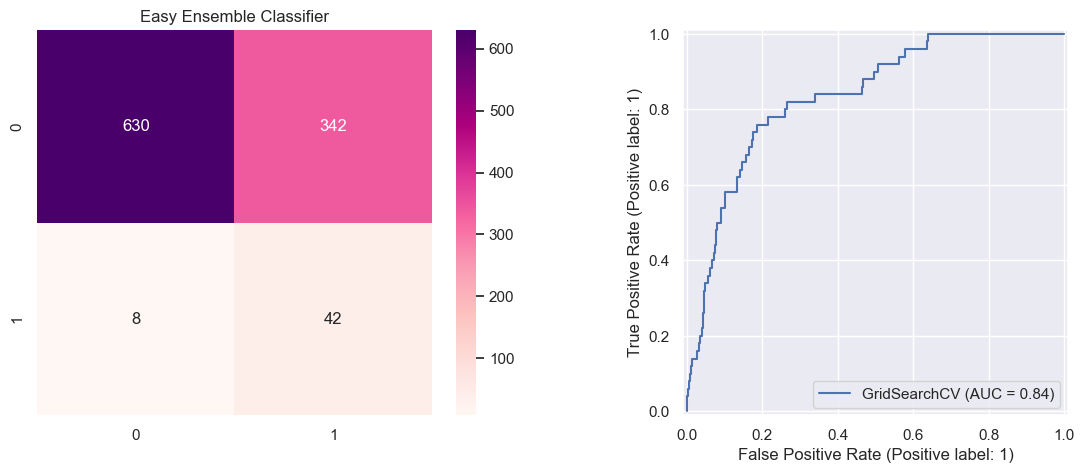

In [367]:
# Pipeline and Grid Search
ee_pipeline = Pipeline([
    ('ee',  EasyEnsembleClassifier(random_state=42))
])

ee_param_grid = {
    'ee__n_estimators': [10, 20], # Number of AdaBoost learners
}

ee_grid = GridSearchCV(ee_pipeline, ee_param_grid, cv=5, scoring='f1', n_jobs=-1)
ee_grid.fit(x_train_scaled, y_train)

# Predictions and Metrics
y_pred_ee = ee_grid.predict(x_test_scaled)
y_proba_ee = ee_grid.predict_proba(x_test_scaled)[:, 1]

print("--- EASY ENSEMBLE RESULTS ---")
print(f"Best Parameters: {ee_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_ee):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ee):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ee):.4f}") # Usually very high
print(f"F1 Score:  {f1_score(y_test, y_pred_ee):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_ee):.4f}")

# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ee), annot=True, fmt='d', cmap='RdPu', ax=ax[0])
ax[0].set_title('Easy Ensemble Classifier')
RocCurveDisplay.from_estimator(ee_grid, x_test_scaled, y_test, ax=ax[1])
plt.show()

### Balanced Random Forest

--- BALANCED RANDOM FOREST RESULTS ---
Best Parameters: {'brf__max_depth': None, 'brf__n_estimators': 200}
Accuracy:  0.6898
Precision: 0.1197
Recall:    0.8400
F1 Score:  0.2095
AUC-ROC:   0.8203


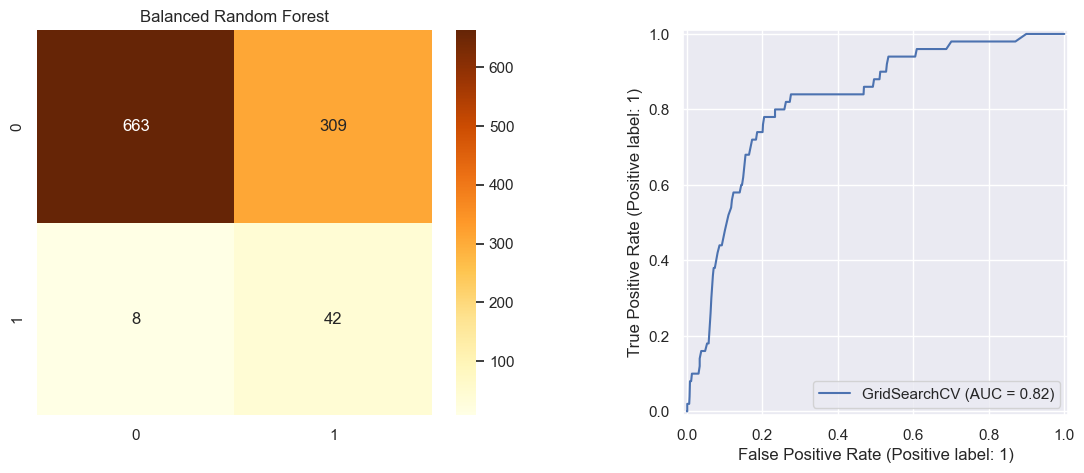

In [368]:
# Pipeline and Grid search
brf_pipeline = Pipeline([
    ('brf', BalancedRandomForestClassifier(random_state=42, sampling_strategy='auto'))
])

brf_param_grid = {
    'brf__n_estimators': [100, 200],
    'brf__max_depth': [10, None]
}

brf_grid = GridSearchCV(brf_pipeline, brf_param_grid, cv=5, scoring='f1', n_jobs=-1)
brf_grid.fit(x_train_scaled, y_train)

# Predictions and Metrics
y_pred_brf = brf_grid.predict(x_test_scaled)
y_proba_brf = brf_grid.predict_proba(x_test_scaled)[:, 1]

print("--- BALANCED RANDOM FOREST RESULTS ---")
print(f"Best Parameters: {brf_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_brf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_brf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_brf):.4f}") # Usually very high
print(f"F1 Score:  {f1_score(y_test, y_pred_brf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_brf):.4f}")


# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_brf), annot=True, fmt='d', cmap='YlOrBr', ax=ax[0])
ax[0].set_title('Balanced Random Forest')
RocCurveDisplay.from_estimator(brf_grid, x_test_scaled, y_test, ax=ax[1])
plt.show()

### Decisison Tree Classifier

--- COST-SENSITIVE DECISION TREE RESULTS ---
Best Parameters: {'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Accuracy:  0.7387
Precision: 0.1322
Recall:    0.7800
F1 Score:  0.2261
AUC-ROC:   0.7986


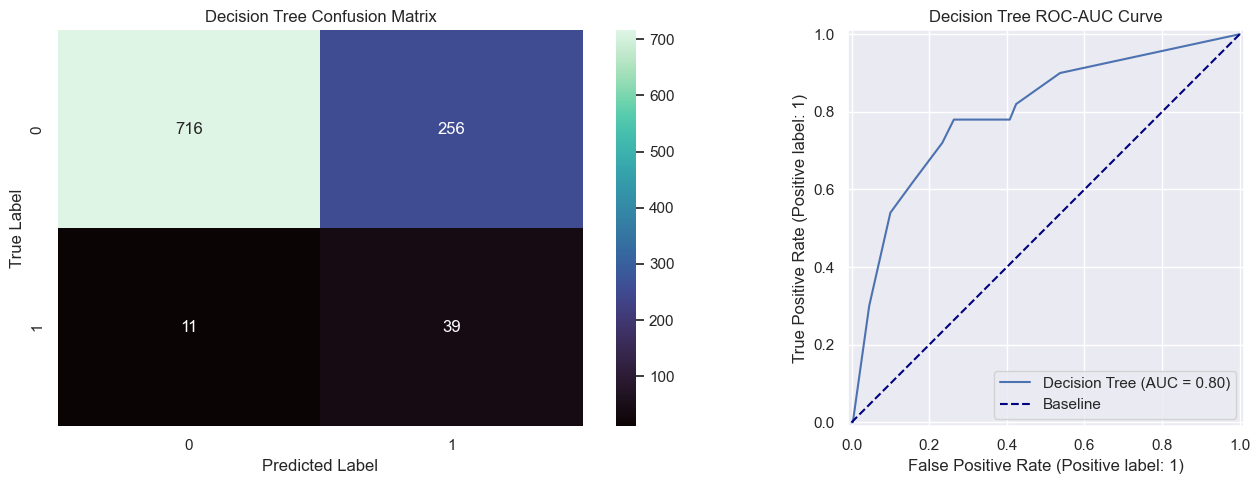

In [351]:
#Pipeline and Grid search

dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

dt_param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [None, 5, 10, 15, 20],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4]
}

# Grid Search (Optimizing for F1)
dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_dt = dt_grid.predict(x_test_scaled)
y_proba_dt = dt_grid.predict_proba(x_test_scaled)[:, 1]

# 6. Output Results
print("--- COST-SENSITIVE DECISION TREE RESULTS ---")
print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_dt):.4f}")

# 7. Graphs (Confusion Matrix & ROC Curve)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='mako', ax=ax[0])
ax[0].set_title('Decision Tree Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# ROC Curve
RocCurveDisplay.from_estimator(dt_grid, x_test_scaled, y_test, ax=ax[1], name='Decision Tree')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--', label='Baseline')
ax[1].set_title('Decision Tree ROC-AUC Curve')
ax[1].legend()

plt.tight_layout()
plt.show()

## SMOTE-Tomek + Random Forest Classifier

--- SMOTE-TOMEK + RANDOM FOREST RESULTS ---
Best Parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
Accuracy:  0.8219
Precision: 0.1292
Recall:    0.4600
F1 Score:  0.2018
AUC-ROC:   0.7753


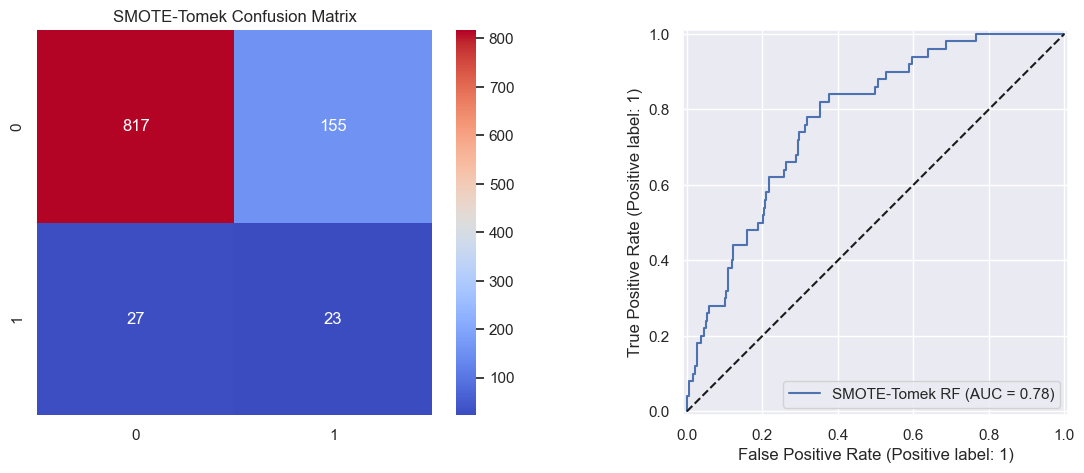

In [352]:
# Pipeline and Grid search


smt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smt', SMOTETomek(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

#Tuning Grid
smt_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_leaf': [1, 2]
}


smt_grid = GridSearchCV(smt_pipeline, smt_param_grid, cv=skf, scoring='f1', n_jobs=-1)
smt_grid.fit(x_train_scaled, y_train)

# 4. Predictions
y_pred_smt = smt_grid.predict(x_test_scaled)
y_proba_smt = smt_grid.predict_proba(x_test_scaled)[:, 1]

# 5. Results
print("--- SMOTE-TOMEK + RANDOM FOREST RESULTS ---")
print(f"Best Parameters: {smt_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_smt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_smt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_smt):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_smt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_smt):.4f}")

# 6. Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_smt), annot=True, fmt='d', cmap='coolwarm', ax=ax[0])
ax[0].set_title('SMOTE-Tomek Confusion Matrix')
RocCurveDisplay.from_estimator(smt_grid, x_test_scaled, y_test, ax=ax[1], name='SMOTE-Tomek RF')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

### LightGBM

--- LIGHTGBM RESULTS ---
Best Parameters: {'lgbm__boosting_type': 'dart', 'lgbm__learning_rate': 0.01, 'lgbm__n_estimators': 200, 'lgbm__num_leaves': 31}
Accuracy:  0.8386
Precision: 0.1925
Recall:    0.7200
F1 Score:  0.3038
AUC-ROC:   0.8446


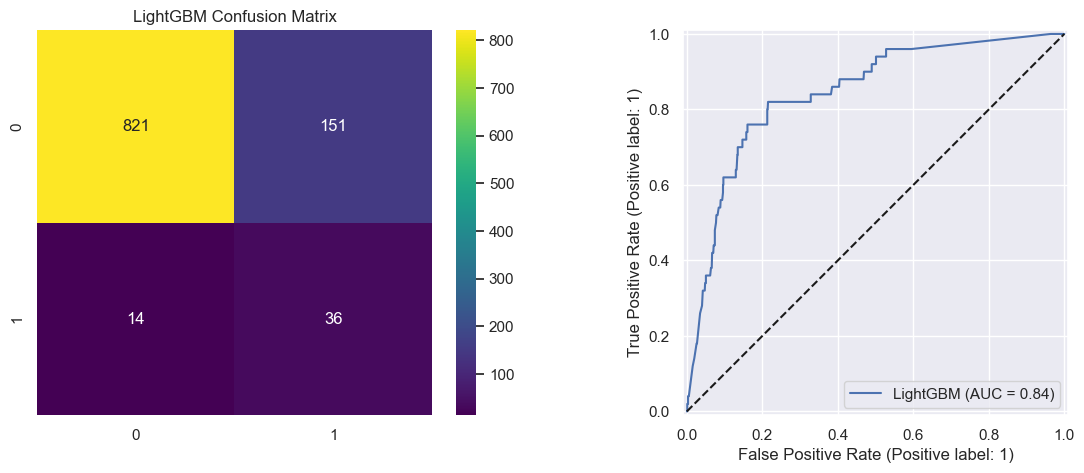

In [353]:
#  Pipeline: Scaler + LightGBM

lgbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', LGBMClassifier(is_unbalance=True, random_state=42, verbosity=-1))
])

# Tuning Grid
lgbm_param_grid = {
    'lgbm__n_estimators': [100, 200],
    'lgbm__learning_rate': [0.01, 0.05, 0.1],
    'lgbm__num_leaves': [31, 50],
    'lgbm__boosting_type': ['gbdt', 'dart']
}

# Grid Search
lgbm_grid = GridSearchCV(lgbm_pipeline, lgbm_param_grid, cv=5, scoring='f1', n_jobs=-1)
lgbm_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_lgbm = lgbm_grid.predict(x_test_scaled)
y_proba_lgbm = lgbm_grid.predict_proba(x_test_scaled)[:, 1]

#  Results
print("--- LIGHTGBM RESULTS ---")
print(f"Best Parameters: {lgbm_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_lgbm):.4f}")

# Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d', cmap='viridis', ax=ax[0])
ax[0].set_title('LightGBM Confusion Matrix')
RocCurveDisplay.from_estimator(lgbm_grid, x_test_scaled, y_test, ax=ax[1], name='LightGBM')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

### CatBoost

--- CATBOOST + SMOTE RESULTS ---
Best Params: {'cat__depth': 4, 'cat__iterations': 100, 'cat__learning_rate': 0.05, 'smote__k_neighbors': 5}
Accuracy:  0.7524
Precision: 0.1413
Recall:    0.8000
F1 Score:  0.2402


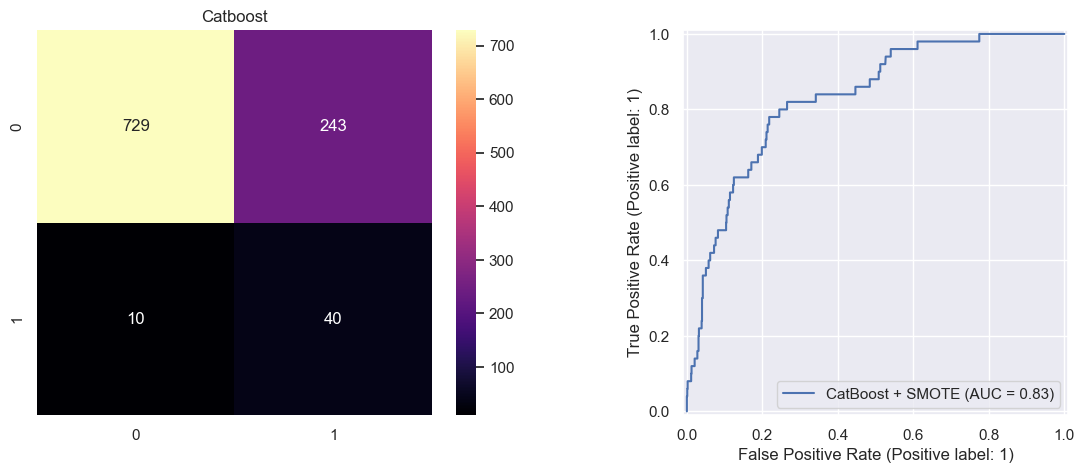

In [369]:
#  Pipeline: Scaler + SMOTE + CatBoost
cat_smote_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('cat', CatBoostClassifier(verbose=False, random_state=42))
])

# Tuning Grid
cat_param_grid = {
    'smote__k_neighbors': [3, 5],
    'cat__iterations': [100, 200],
    'cat__depth': [4, 6],
    'cat__learning_rate': [0.05, 0.1]
}

# Grid Search
cat_smote_grid = GridSearchCV(cat_smote_pipeline, cat_param_grid, cv=5, scoring='f1', n_jobs=-1)
cat_smote_grid.fit(x_train, y_train)

# Predictions
y_pred_cat = cat_smote_grid.predict(x_test)
y_proba_cat = cat_smote_grid.predict_proba(x_test)[:, 1]

print("--- CATBOOST + SMOTE RESULTS ---")
print(f"Best Params: {cat_smote_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cat):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cat):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cat):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_cat):.4f}")

# 5. Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_cat), annot=True, fmt='d', cmap='magma', ax=ax[0])
ax[0].set_title('Catboost')
RocCurveDisplay.from_estimator(cat_smote_grid, x_test, y_test, ax=ax[1], name='CatBoost + SMOTE')
plt.show()

### Hist-Gradient Boosting

--- HIST-GRADIENT BOOSTING RESULTS ---
Best Parameters: {'hgb__l2_regularization': 0, 'hgb__learning_rate': 0.01, 'hgb__max_depth': None, 'hgb__max_iter': 200}
Accuracy:  0.8180
Precision: 0.1699
Recall:    0.7000
F1 Score:  0.2734
AUC-ROC:   0.8356


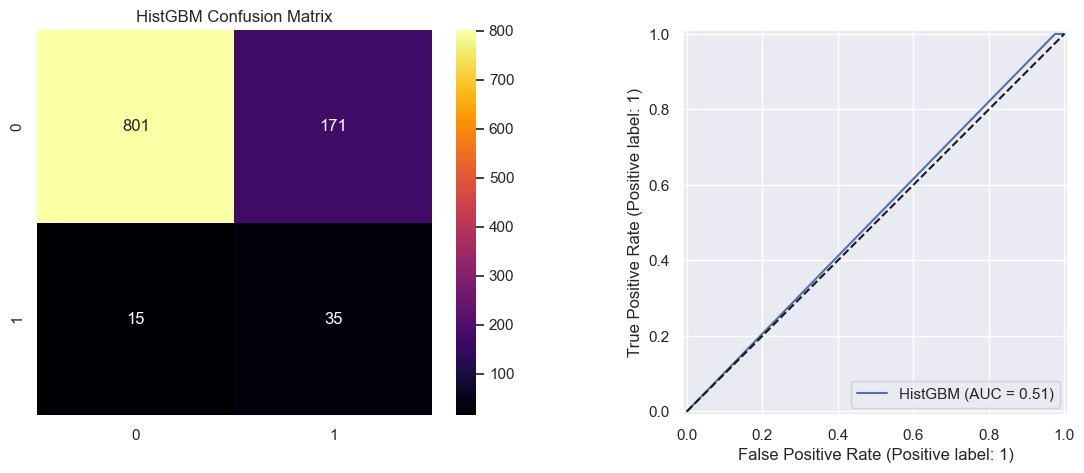

In [355]:
# Pipeline: Scaler + HistGradientBoosting
hgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('hgb', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
])

#Tuning the Grid
hgb_param_grid = {
    'hgb__max_iter': [100, 200],
    'hgb__max_depth': [5, 10, None],
    'hgb__learning_rate': [0.01, 0.05, 0.1],
    'hgb__l2_regularization': [0, 0.1, 1.0] # Helps prevent overfitting
}

# Grid Search
hgb_grid = GridSearchCV(hgb_pipeline, hgb_param_grid, cv=skf, scoring='f1', n_jobs=-1)
hgb_grid.fit(x_train_scaled, y_train)

# Predictions
y_pred_hgb = hgb_grid.predict(x_test_scaled)
y_proba_hgb = hgb_grid.predict_proba(x_test_scaled)[:, 1]

#Outputing Results
print("--- HIST-GRADIENT BOOSTING RESULTS ---")
print(f"Best Parameters: {hgb_grid.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_hgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_hgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_hgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_hgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_hgb):.4f}")

# Visual Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_hgb), annot=True, fmt='d', cmap='inferno', ax=ax[0])
ax[0].set_title('HistGBM Confusion Matrix')
RocCurveDisplay.from_estimator(hgb_grid, x_test, y_test, ax=ax[1], name='HistGBM')
ax[1].plot([0, 1], [0, 1], 'k--')
plt.show()

## MODELS COMPARISON

In [371]:
# All models and their predictions + probabilities
models_results = {
    'Logistic Regression':   (y_pred,      y_proba),
    'Random Forest':         (y_pred_rf,   y_proba_rf),
    'XGBoost':               (y_pred_xgb,  y_proba_xgb),
    'SVC':                   (y_pred_svc,  y_proba_svc),
    'AdaBoost':              (y_pred_ada,  y_proba_ada),
    'Balanced Bagging':      (y_pred_bbc,  y_proba_bbc),
    'KNN':                   (y_pred_knn,  y_proba_knn),
    'Naive Bayes':           (y_pred_gnb,  y_proba_gnb),
    'EasyEnsemble':          (y_pred_ee,   y_proba_ee),
    'Balanced RF':           (y_pred_brf,  y_proba_brf),
    'Decision Tree':         (y_pred_dt,   y_proba_dt),
    'SMOTETomek + RF':       (y_pred_smt,  y_proba_smt),
    'LightGBM':              (y_pred_lgbm, y_proba_lgbm),
    'CatBoost':              (y_pred_cat,  y_proba_cat),
    'HistGradientBoosting':  (y_pred_hgb,  y_proba_hgb),
}

# Building the results DataFrame
results = []
for name, (pred, proba) in models_results.items():
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, pred),               4),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred),                  4),
        'F1 Score':  round(f1_score(y_test, pred),                      4),
        'ROC-AUC':   round(roc_auc_score(y_test, proba),                4),
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df.index += 1  # Rank starts from 1

(results_df.style
    .background_gradient(subset=['ROC-AUC'],  cmap='YlGn',   vmin=0.6, vmax=1.0)
    .background_gradient(subset=['Recall'],   cmap='YlGn',   vmin=0.0, vmax=1.0)
    .background_gradient(subset=['F1 Score'], cmap='YlGn',   vmin=0.0, vmax=0.5)
    .background_gradient(subset=['Accuracy'], cmap='YlOrRd', vmin=0.5, vmax=1.0)
    .background_gradient(subset=['Precision'],cmap='YlOrRd', vmin=0.0, vmax=1.0)
    .set_properties(**{
        'text-align':  'center',
        'font-size':   '12px',
        'font-family': 'Calibri',
        'border':      '1px solid #cccccc',
        'padding':     '6px 12px',
    })
    .set_table_styles([
        # Header row styling
        {'selector': 'thead th',
         'props': [('background-color', '#007B7F'),
                   ('color',            'white'),
                   ('font-weight',      'bold'),
                   ('font-size',        '13px'),
                   ('text-align',       'center'),
                   ('padding',          '8px 12px'),
                   ('border',           '1px solid white')]},
        # Alternating row shading
        {'selector': 'tbody tr:nth-child(even)',
         'props': [('background-color', '#f0f7f7')]},
        {'selector': 'tbody tr:nth-child(odd)',
         'props': [('background-color', '#ffffff')]},
        # Hover effect
        {'selector': 'tbody tr:hover',
         'props': [('background-color', '#d0eeee !important'),
                   ('cursor',           'pointer')]},
        # Table border
        {'selector': 'table',
         'props': [('border-collapse', 'separate'),
                   ('border-spacing',  '0'),
                   ('border-radius',   '8px'),
                   ('overflow',        'hidden'),
                   ('width',           '100%')]},
    ])
    .format({
        'Accuracy':  '{:.2%}',
        'Precision': '{:.2%}',
        'Recall':    '{:.2%}',
        'F1 Score':  '{:.4f}',
        'ROC-AUC':   '{:.4f}',
    })
    .set_caption('Model Performance Comparison — Sorted by F1 scores')
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,LightGBM,83.86%,19.25%,72.00%,0.3038,0.8446
2,HistGradientBoosting,81.80%,16.99%,70.00%,0.2734,0.8356
3,XGBoost,84.05%,16.57%,56.00%,0.2557,0.8107
4,Balanced Bagging,77.50%,14.84%,76.00%,0.2484,0.8144
5,AdaBoost,77.10%,14.34%,74.00%,0.2403,0.8103
6,CatBoost,75.24%,14.13%,80.00%,0.2402,0.8306
7,Decision Tree,73.87%,13.22%,78.00%,0.2261,0.7986
8,SVC,72.50%,12.62%,78.00%,0.2173,0.8109
9,Balanced RF,68.98%,11.97%,84.00%,0.2095,0.8203
10,SMOTETomek + RF,82.19%,12.92%,46.00%,0.2018,0.7753


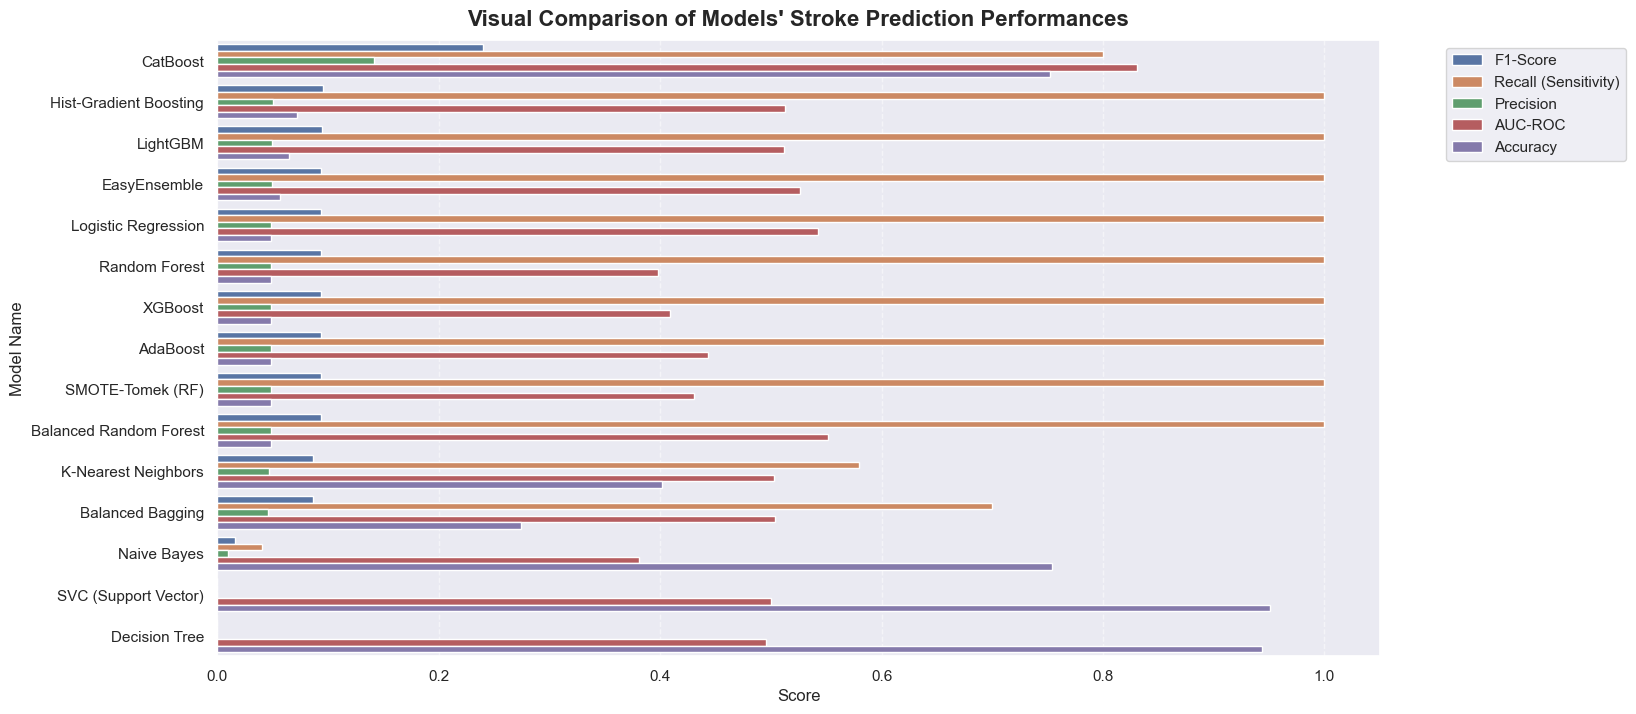

In [357]:
## Graphical Model Comparison

all_models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "LightGBM": lgbm_grid.best_estimator_,
    "CatBoost": cat_smote_grid.best_estimator_,
    "Hist-Gradient Boosting": hgb_grid.best_estimator_,
    "SVC (Support Vector)": svc_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "K-Nearest Neighbors": knn_grid.best_estimator_,
    "Naive Bayes": gnb_grid.best_estimator_,
    "AdaBoost": ada_grid.best_estimator_,
    "EasyEnsemble": ee_grid.best_estimator_,
    "Balanced Bagging": bbc_grid.best_estimator_,
    "SMOTE-Tomek (RF)": smt_grid.best_estimator_,
    "Balanced Random Forest": brf_grid.best_estimator_
}

#Extracting results using the x_test and y_test:
comparison_results = []

for name, model in all_models.items():
    y_pred = model.predict(x_test)
    
    # Calculating the AUC-ROC using predict_proba
    try:
        y_proba = model.predict_proba(x_test)[:, 1]
        auc_val = roc_auc_score(y_test, y_proba)
    except:
        auc_val = None # This is to create a Fallback if a model doesn't support probabilities
    
    comparison_results.append({
        "Model Name": name,
        "F1-Score": f1_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "AUC-ROC": auc_val,
        "Accuracy": accuracy_score(y_test, y_pred)
    })

# Creating A full model comparison table sorted by the F1-Score:
models_compared = pd.DataFrame(comparison_results).sort_values(by="F1-Score", ascending=False)



# 5. Visualizing the performance metrics:
plt.figure(figsize=(15, 8))
plot_df = models_compared.melt(id_vars="Model Name", var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Score", y="Model Name", hue="Metric")
plt.title("Visual Comparison of Models' Stroke Prediction Performances", fontsize=16, fontweight='bold', y=1.01)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

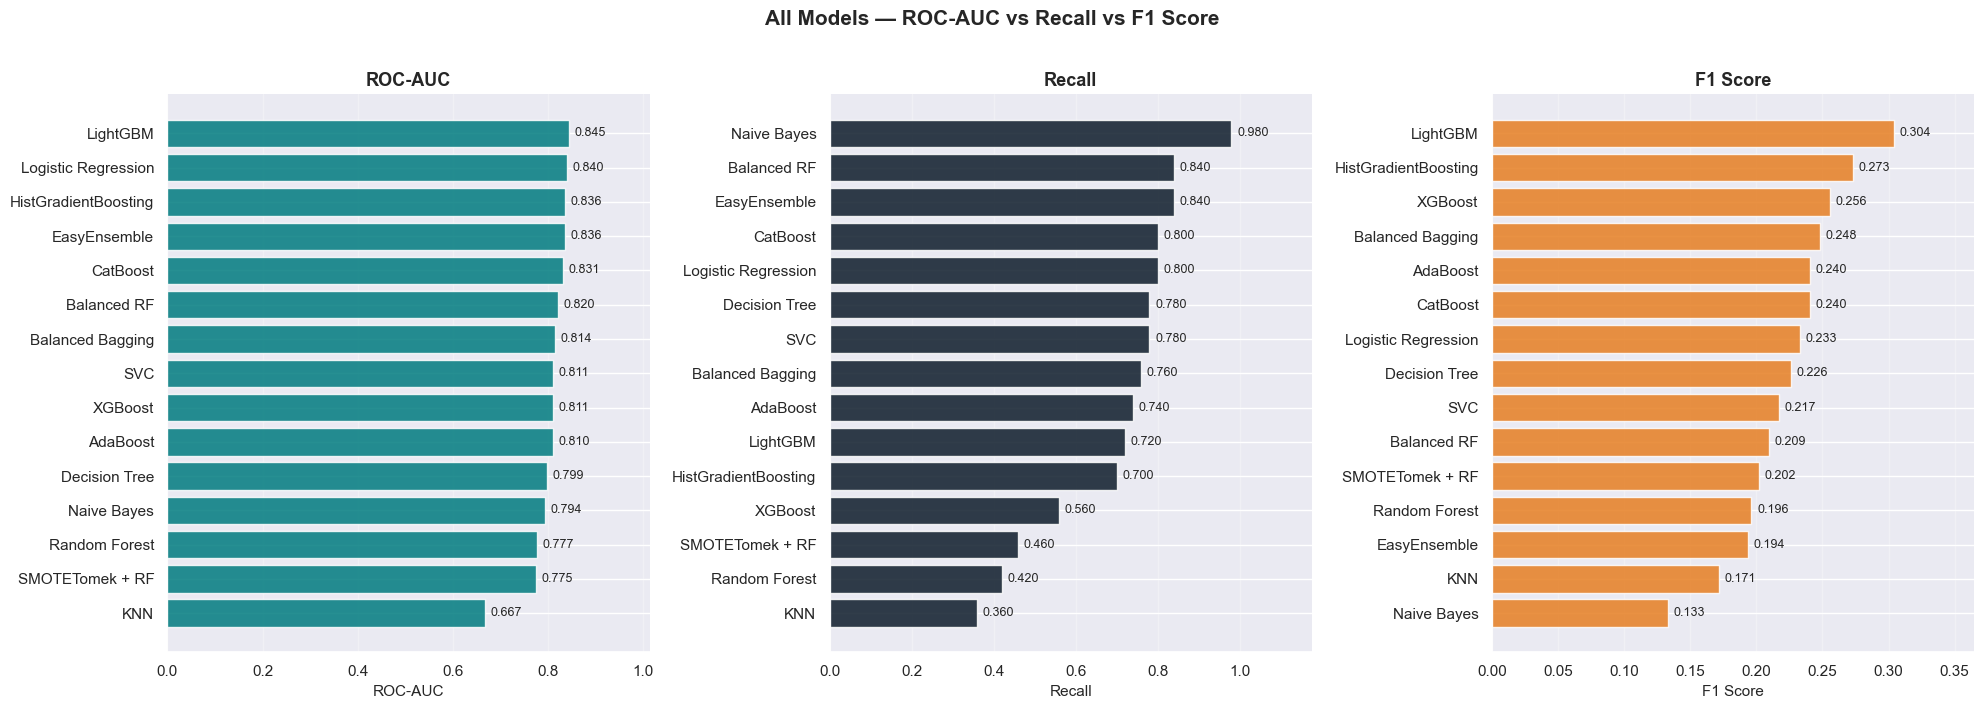

In [358]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

metrics = ['ROC-AUC', 'Recall', 'F1 Score']
colors  = ['#007B7F', '#0D1B2A', '#E67E22']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric, fontsize=11)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.set_xlim(0, sorted_df[metric].max() * 1.2)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('All Models — ROC-AUC vs Recall vs F1 Score',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

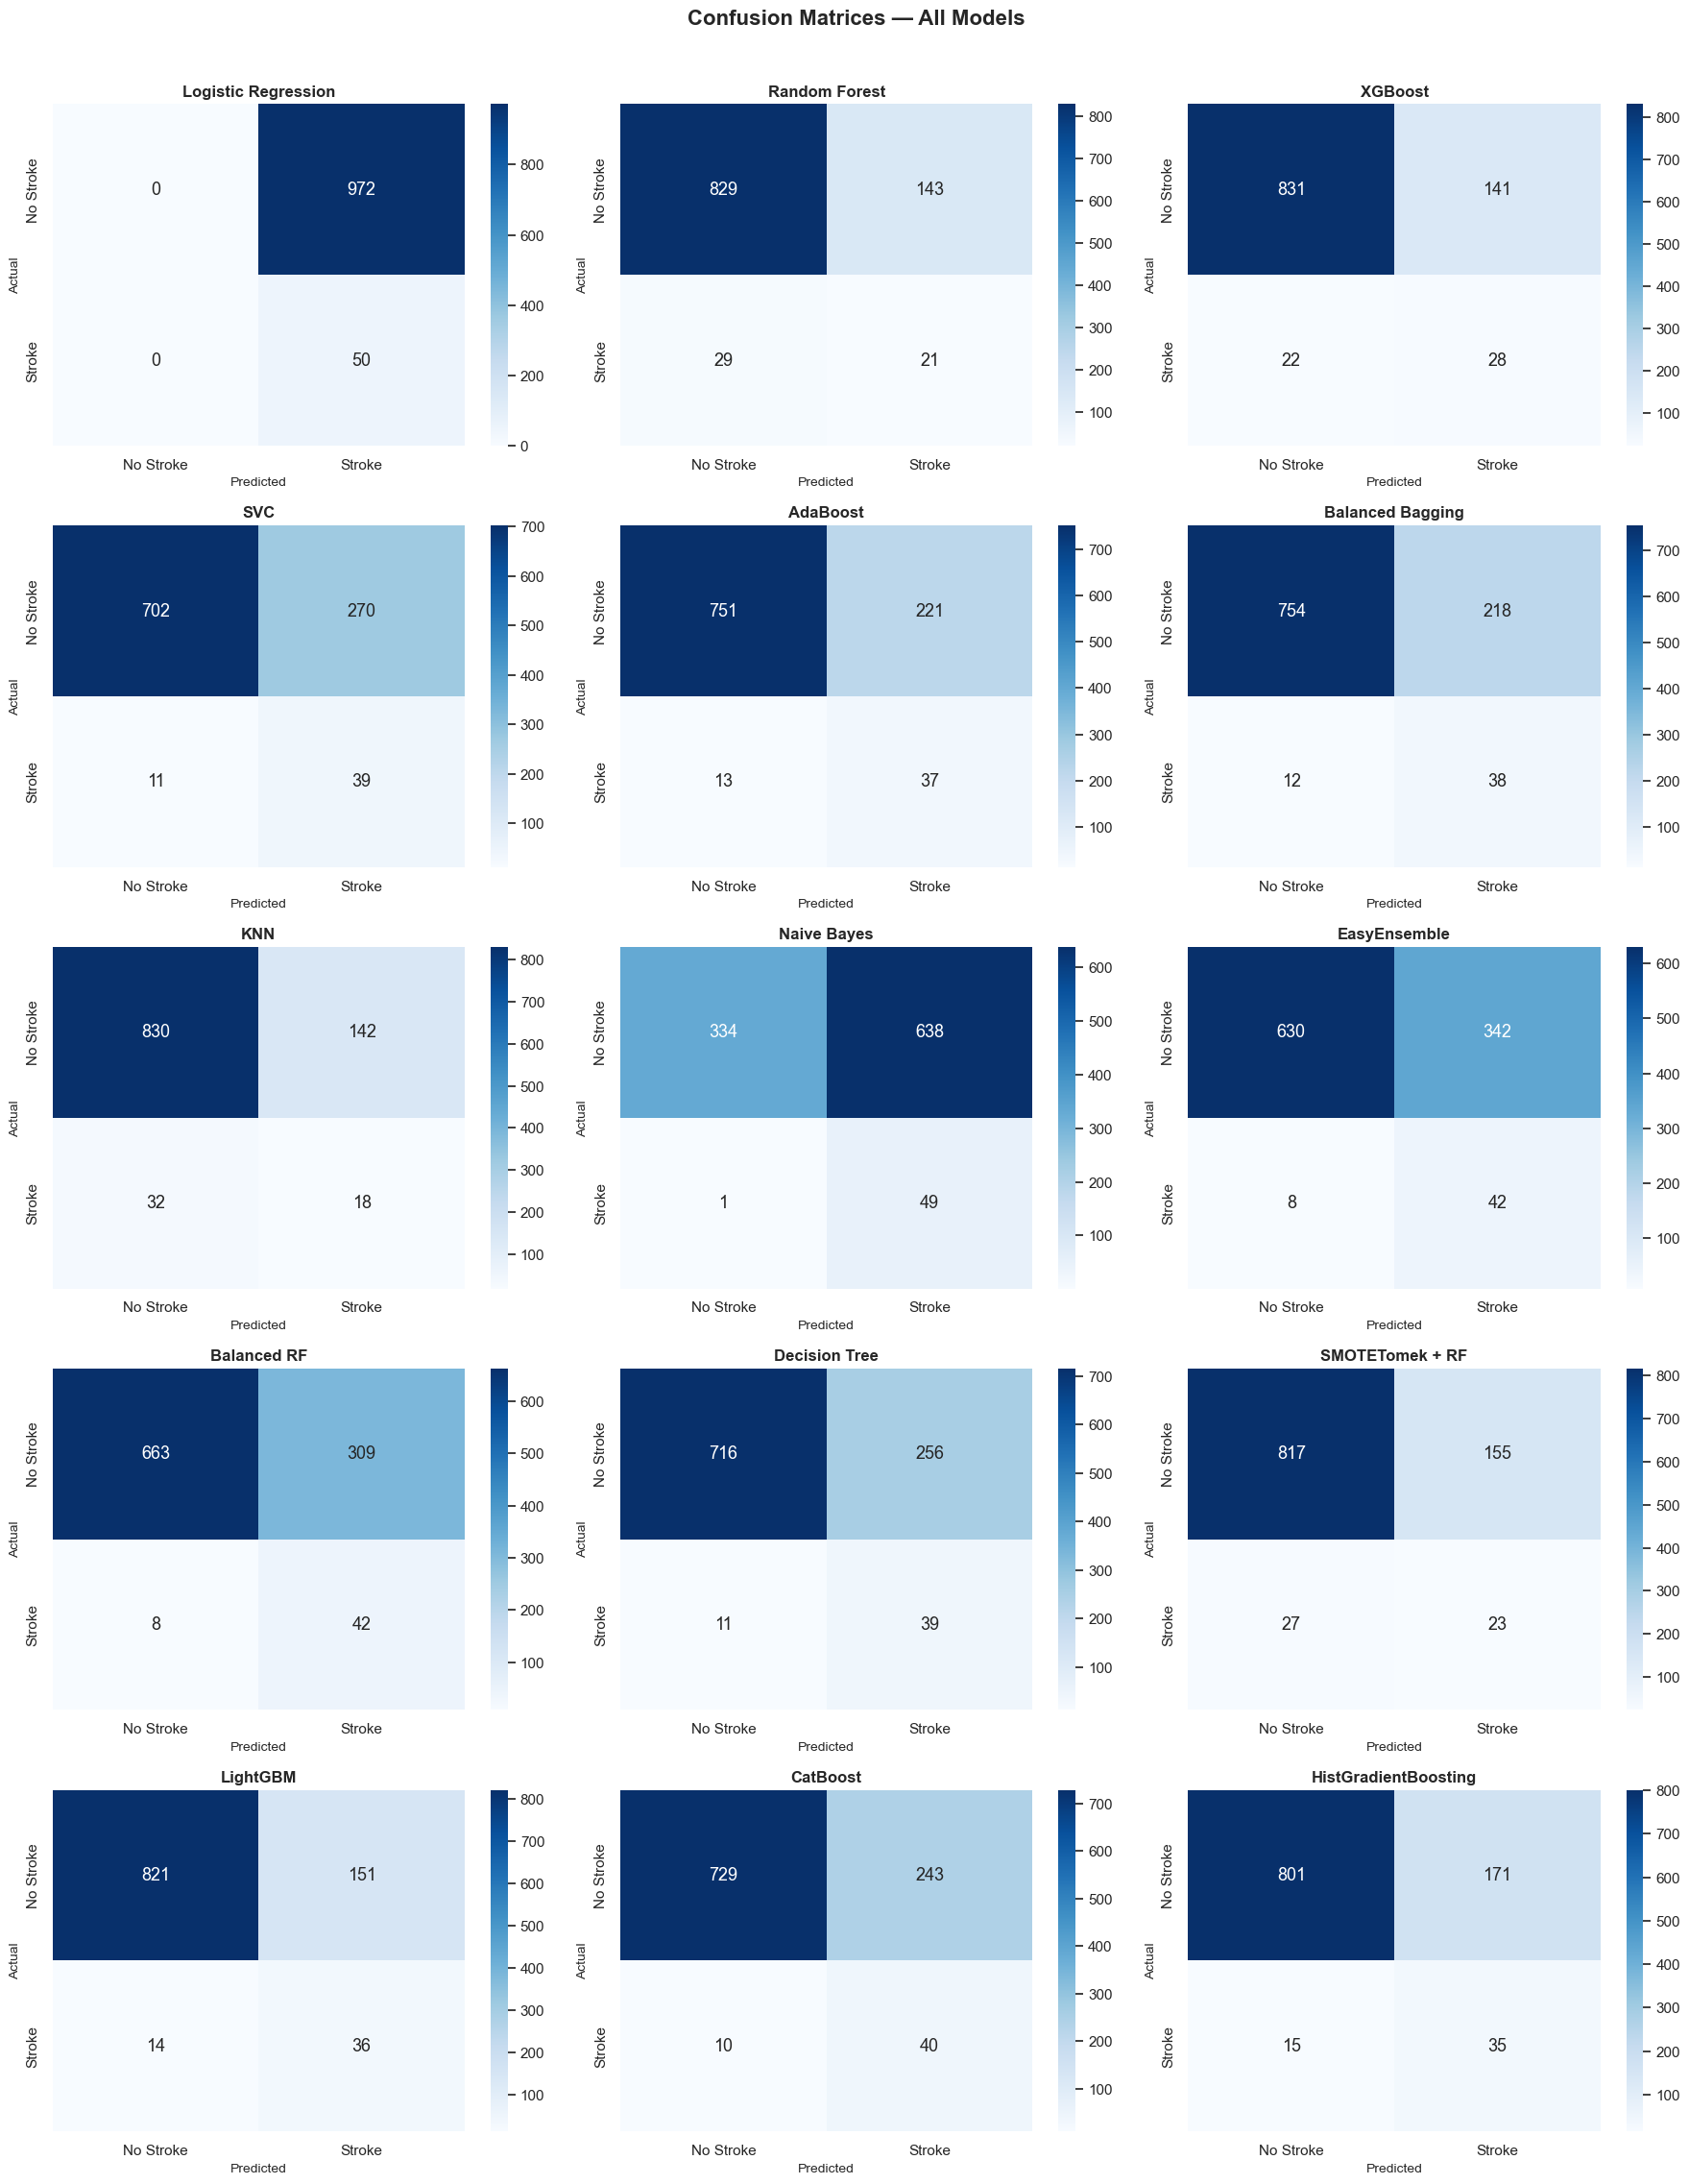

In [359]:
# Confusion Matrices For All Models

models_preds = {
    'Logistic Regression': y_pred,
    'Random Forest':       y_pred_rf,
    'XGBoost':             y_pred_xgb,
    'SVC':                 y_pred_svc,
    'AdaBoost':            y_pred_ada,
    'Balanced Bagging':    y_pred_bbc,
    'KNN':                 y_pred_knn,
    'Naive Bayes':         y_pred_gnb,
    'EasyEnsemble':        y_pred_ee,
    'Balanced RF':         y_pred_brf,
    'Decision Tree':       y_pred_dt,
    'SMOTETomek + RF':     y_pred_smt,
    'LightGBM':            y_pred_lgbm,
    'CatBoost':            y_pred_cat,
    'HistGradientBoosting':y_pred_hgb,
}

n = len(models_preds)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4.5))
axes = axes.flatten()

for i, (name, pred) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'],
                annot_kws={"size": 13})
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

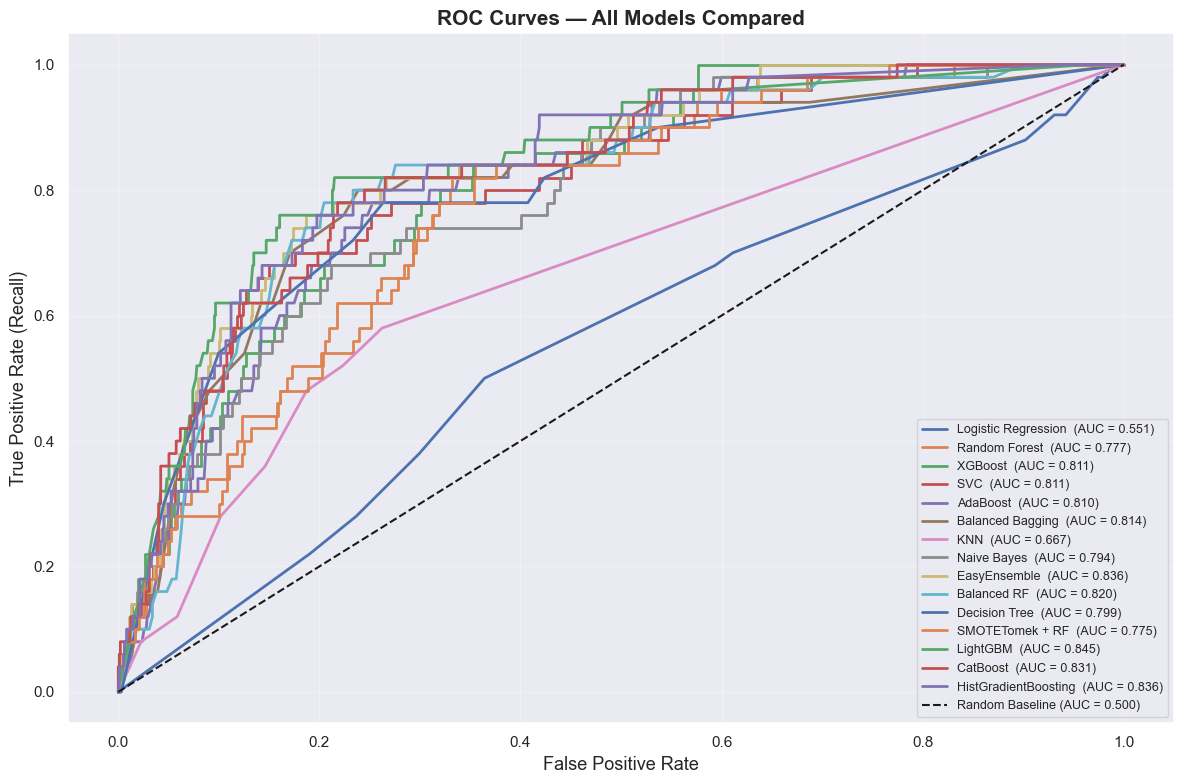

In [374]:
#Graphical representation of ROC curves for all models

models_probas = {
    'Logistic Regression':  y_proba,
    'Random Forest':        y_proba_rf,
    'XGBoost':              y_proba_xgb,
    'SVC':                  y_proba_svc,
    'AdaBoost':             y_proba_ada,
    'Balanced Bagging':     y_proba_bbc,
    'KNN':                  y_proba_knn,
    'Naive Bayes':          y_proba_gnb,
    'EasyEnsemble':         y_proba_ee,
    'Balanced RF':          y_proba_brf,
    'Decision Tree':        y_proba_dt,
    'SMOTETomek + RF':      y_proba_smt,
    'LightGBM':             y_proba_lgbm,
    'CatBoost':             y_proba_cat,
    'HistGradientBoosting': y_proba_hgb,
}

plt.figure(figsize=(12, 8))

for name, proba in models_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name}  (AUC = {auc:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate (Recall)', fontsize=13)
plt.title('ROC Curves — All Models Compared', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [361]:
#Finding the Best Model Automatically

best_model_name = results_df.iloc[0]['Model']
best_roc_auc    = results_df.iloc[0]['ROC-AUC']
best_recall     = results_df.iloc[0]['Recall']
best_f1         = results_df.iloc[0]['F1 Score']

print("=" * 50)
print(f" BEST MODEL SELECTED")
print("=" * 50)
print(f"  Model     : {best_model_name}")
print(f"  ROC-AUC   : {best_roc_auc:.4f}")
print(f"  Recall    : {best_recall:.4f}")
print(f"  F1 Score  : {best_f1:.4f}")
print("=" * 50)

 BEST MODEL SELECTED
  Model     : LightGBM
  ROC-AUC   : 0.8446
  Recall    : 0.7200
  F1 Score  : 0.3038


## Feature Importance

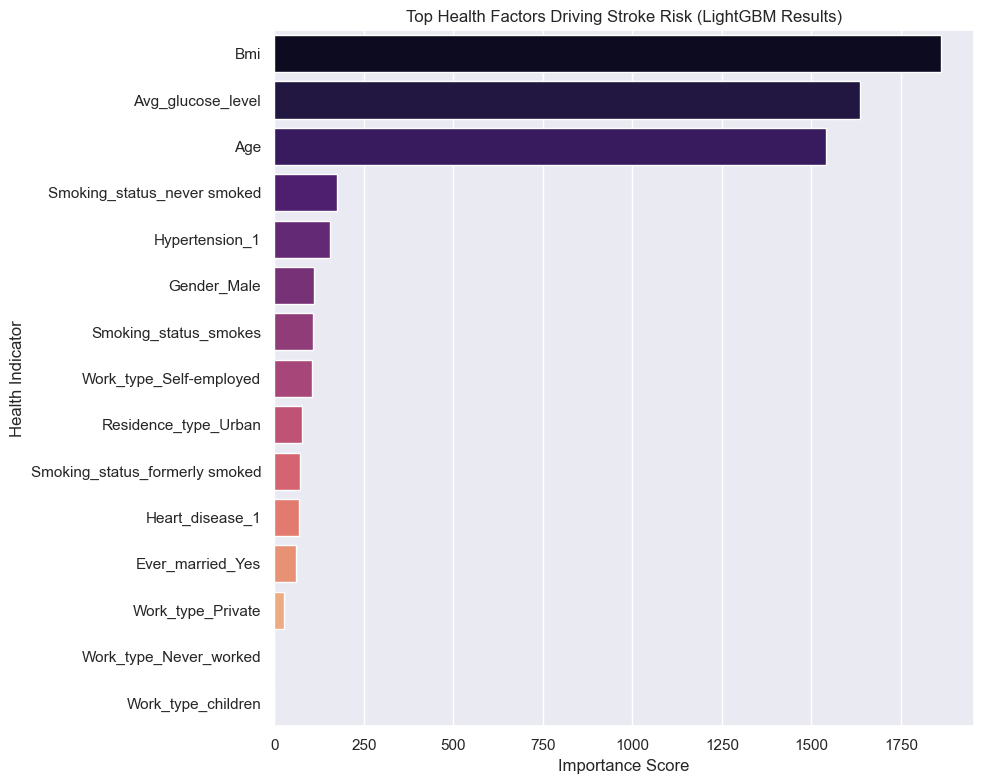

The top 3 predictors for your winning model are:
1. Bmi
2. Avg_glucose_level
3. Age


In [373]:
# Accessing the best LightGBM model from the grid search pipeline

best_lgbm_pipeline = lgbm_grid.best_estimator_

lgbm_classifier = best_lgbm_pipeline.named_steps['lgbm']

# Matching importance scores with feature names from x_train_scaled
feature_names = x_train.columns
importances = lgbm_classifier.feature_importances_

# Creation of DataFrame for easy sorting and plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='magma')
plt.title('Top Health Factors Driving Stroke Risk (LightGBM Results)')
plt.xlabel('Importance Score')
plt.ylabel('Health Indicator')
plt.tight_layout()
plt.show()

# Printing top 3  features for your conclusion
print(f"The top 3 predictors for your winning model are:")
for i in range(3):
    print(f"{i+1}. {feat_imp_df.iloc[i]['Feature']}")

## OPTIMIZATION

--- THRESHOLD EXPLORATION TABLE ---
   Threshold  F1-Score  Recall  Precision
0       0.05  0.093284    1.00   0.048924
1       0.10  0.093284    1.00   0.048924
2       0.15  0.093284    1.00   0.048924
3       0.20  0.096525    1.00   0.050710
4       0.25  0.177778    0.88   0.098876
5       0.30  0.193548    0.84   0.109375
6       0.35  0.222222    0.82   0.128527
7       0.40  0.257862    0.82   0.152985
8       0.45  0.276364    0.76   0.168889
9       0.50  0.303797    0.72   0.192513


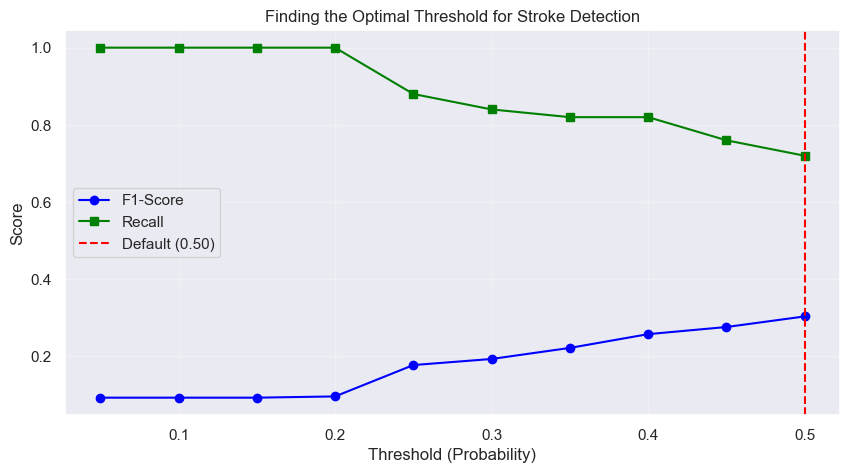

In [364]:
# Getting the probabilities from our best model
y_probs = lgbm_grid.best_estimator_.predict_proba(x_test_scaled)[:, 1]

# Testing ranges of thresholds from 0.05 to 0.50
thresholds = np.arange(0.05, 0.55, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    results.append({
        "Threshold": round(t, 2),
        "F1-Score": f1_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t)
    })

# Creating a comparison table
threshold_df = pd.DataFrame(results)

print("--- THRESHOLD EXPLORATION TABLE ---")
print(threshold_df)

# visualisation
plt.figure(figsize=(10, 5))
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score'], label='F1-Score', marker='o', color='blue')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall', marker='s', color='green')
plt.axvline(x=0.5, color='red', linestyle='--', label='Default (0.50)')
plt.title("Finding the Optimal Threshold for Stroke Detection")
plt.xlabel("Threshold (Probability)")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [362]:
#Saving The Best Model

trained_models = {
    'Logistic Regression':  grid_search,
    'Random Forest':        rf_grid,
    'XGBoost':              xgb_grid,
    'SVC':                  svc_grid,
    'AdaBoost':             ada_grid,
    'Balanced Bagging':     bbc_grid,
    'KNN':                  knn_grid,
    'Naive Bayes':          gnb_grid,
    'EasyEnsemble':         ee_grid,
    'Balanced RF':          brf_grid,
    'Decision Tree':        dt_grid,
    'SMOTETomek + RF':      smt_grid,
    'LightGBM':             lgbm_grid,
    'CatBoost':             cat_smote_grid,
    'HistGradientBoosting': hgb_grid,
}

# Getting the best model object
best_model_obj = trained_models[best_model_name].best_estimator_

# Save to file
save_path = 'best_stroke_model.pkl'
joblib.dump(best_model_obj, save_path)

print(f" Model saved successfully!")
print(f" File : {save_path}")
print(f" Size : {os.path.getsize(save_path) / 1024:.1f} KB")

 Model saved successfully!
 File : best_stroke_model.pkl
 Size : 687.2 KB


In [365]:
#Confirming our saved models

#Loading the model
loaded_model = joblib.load('best_stroke_model.pkl')

# predictions using loaded model
loaded_pred  = loaded_model.predict(x_test_scaled)
loaded_proba = loaded_model.predict_proba(x_test_scaled)[:, 1]

print("=" * 50)
print("  MODEL LOADED & VERIFIED")
print("=" * 50)
print(f"  Accuracy : {accuracy_score(y_test, loaded_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, loaded_proba):.4f}")
print(f"  Recall   : {recall_score(y_test, loaded_pred):.4f}")
print(f"  F1 Score : {f1_score(y_test, loaded_pred):.4f}")
print("=" * 50)
print("\n  Scores match original — model saved correctly ")

  MODEL LOADED & VERIFIED
  Accuracy : 0.8386
  ROC-AUC  : 0.8446
  Recall   : 0.7200
  F1 Score : 0.3038

  Scores match original — model saved correctly 


## Checking Our Model on a Simulated new dataset

In [366]:
#Simulating a dataset for a new patient

sample_patient = pd.DataFrame([{
    'Age':                          67,
    'Avg_glucose_level':            228.69,
    'Bmi':                          36.6,
    'Gender_Male':                  1,
    'Ever_married_Yes':             1,
    'Work_type_Never_worked':       0,
    'Work_type_Private':            1,
    'Work_type_Self-employed':      0,
    'Work_type_children':           0,
    'Residence_type_Urban':         1,
    'Smoking_status_formerly smoked': 1,
    'Smoking_status_never smoked':  0,
    'Smoking_status_smokes':        0,
    'Smoking_status_Unknown':       0,
    'Hypertension_1':               1,
    'Heart_disease_1':              1,
}])

# Aligning columns to match training data exactly
sample_patient = sample_patient.reindex(columns=x_train.columns, fill_value=0)

# Prediction
stroke_proba = loaded_model.predict_proba(sample_patient)[:, 1][0]
stroke_pred  = loaded_model.predict(sample_patient)[0]

print("=" * 50)
print("   NEW PATIENT STROKE RISK ASSESSMENT")
print("=" * 50)
print(f"  Age              : 67")
print(f"  Glucose Level    : 228.69 mg/dL (High)")
print(f"  BMI              : 36.6 (Obese)")
print(f"  Hypertension     : Yes")
print(f"  Heart Disease    : Yes")
print(f"  Smoking          : Formerly Smoked")
print("-" * 50)
print(f"  Stroke Probability : {stroke_proba:.2%}")
print(f"  Prediction         : {'HIGH RISK — Stroke Likely' if stroke_pred == 1 else ' LOW RISK — No Stroke'}")
print("=" * 50)

   NEW PATIENT STROKE RISK ASSESSMENT
  Age              : 67
  Glucose Level    : 228.69 mg/dL (High)
  BMI              : 36.6 (Obese)
  Hypertension     : Yes
  Heart Disease    : Yes
  Smoking          : Formerly Smoked
--------------------------------------------------
  Stroke Probability : 55.95%
  Prediction         : HIGH RISK — Stroke Likely
